In [2]:
import pandas as pd

In [3]:
japan_df = pd.read_csv('japan_financial_stats.csv', encoding="utf-8")
japan_df

,Unnamed: 0,"Economic Activity, Industrial Production, Index","Exchange Rates, National Currency Per U.S. Dollar, Period Average, Rate","International Reserves and Liquidity, Reserves, Official Reserve Assets, US Dollar","Prices, Consumer Price Index, All items, Index"
0,Dec 1959,12.14,360.00,"1,446.26",18.52
1,Jan 1960,11.23,360.00,"1,453.30",18.75
2,Feb 1960,12.64,360.00,"1,446.33",18.77
3,Mar 1960,13.63,360.00,"1,486.37",18.71
4,Apr 1960,12.72,360.00,"1,510.40",18.83
...,...,...,...,...,...
368,Aug 1990,97.70,147.42,"77,255.03",94.49
369,Sep 1990,106.07,138.99,"77,520.17",95.22
370,Oct 1990,108.06,129.73,"78,465.27",96.25
371,Nov 1990,106.47,129.08,"78,941.10",96.05


In [4]:
usa_df = pd.read_csv('us_financial_stats.csv', encoding="utf-8")
usa_df

,Unnamed: 0,"International Reserves and Liquidity, Reserves, Official Reserve Assets, US Dollar","Prices, Consumer Price Index, All items, Index"
0,Dec 1959,"21,504.50",13.48
1,Jan 1960,"21,478.10",13.44
2,Feb 1960,"21,395.70",13.48
3,Mar 1960,"21,344.70",13.48
4,Apr 1960,"21,278.00",13.53
...,...,...,...
368,Aug 1990,"78,908.84",60.35
369,Sep 1990,"80,024.17",60.86
370,Oct 1990,"82,852.20",61.22
371,Nov 1990,"83,059.40",61.36


In [5]:
japan_df.columns = (
    japan_df.columns.str.lower()  # Convert to lowercase
    .str.replace(r"[^a-zA-Z0-9]", "_", regex=True)  # Replace special characters with underscores
    .str.replace(r"__+", "_", regex=True)  # Remove double underscores
    .str.strip("_")  # Remove leading/trailing underscores
    + "_japan" # Ensure country can be identified
)
japan_df

,unnamed_0_japan,economic_activity_industrial_production_index_japan,exchange_rates_national_currency_per_u_s_dollar_period_average_rate_japan,international_reserves_and_liquidity_reserves_official_reserve_assets_us_dollar_japan,prices_consumer_price_index_all_items_index_japan
0,Dec 1959,12.14,360.00,"1,446.26",18.52
1,Jan 1960,11.23,360.00,"1,453.30",18.75
2,Feb 1960,12.64,360.00,"1,446.33",18.77
3,Mar 1960,13.63,360.00,"1,486.37",18.71
4,Apr 1960,12.72,360.00,"1,510.40",18.83
...,...,...,...,...,...
368,Aug 1990,97.70,147.42,"77,255.03",94.49
369,Sep 1990,106.07,138.99,"77,520.17",95.22
370,Oct 1990,108.06,129.73,"78,465.27",96.25
371,Nov 1990,106.47,129.08,"78,941.10",96.05


In [6]:
usa_df.columns = (
    usa_df.columns.str.lower()  # Convert to lowercase
    .str.replace(r"[^a-zA-Z0-9]", "_", regex=True)  # Replace special characters with underscores
    .str.replace(r"__+", "_", regex=True)  # Remove double underscores
    .str.strip("_")  # Remove leading/trailing underscores
    + "_usa" # Ensure country can be identified
)
usa_df

,unnamed_0_usa,international_reserves_and_liquidity_reserves_official_reserve_assets_us_dollar_usa,prices_consumer_price_index_all_items_index_usa
0,Dec 1959,"21,504.50",13.48
1,Jan 1960,"21,478.10",13.44
2,Feb 1960,"21,395.70",13.48
3,Mar 1960,"21,344.70",13.48
4,Apr 1960,"21,278.00",13.53
...,...,...,...
368,Aug 1990,"78,908.84",60.35
369,Sep 1990,"80,024.17",60.86
370,Oct 1990,"82,852.20",61.22
371,Nov 1990,"83,059.40",61.36


In [7]:
# Rename 'Unnamed: 0' to 'Date' in both DataFrames
japan_df.rename(columns={"unnamed_0_japan": "date"}, inplace=True)
usa_df.rename(columns={"unnamed_0_usa": "date"}, inplace=True)

In [8]:
# Perform an inner merge on 'Date'
merged_df = pd.merge(japan_df, usa_df, on="date", how="inner")
merged_df

,date,economic_activity_industrial_production_index_japan,exchange_rates_national_currency_per_u_s_dollar_period_average_rate_japan,international_reserves_and_liquidity_reserves_official_reserve_assets_us_dollar_japan,prices_consumer_price_index_all_items_index_japan,international_reserves_and_liquidity_reserves_official_reserve_assets_us_dollar_usa,prices_consumer_price_index_all_items_index_usa
0,Dec 1959,12.14,360.00,"1,446.26",18.52,"21,504.50",13.48
1,Jan 1960,11.23,360.00,"1,453.30",18.75,"21,478.10",13.44
2,Feb 1960,12.64,360.00,"1,446.33",18.77,"21,395.70",13.48
3,Mar 1960,13.63,360.00,"1,486.37",18.71,"21,344.70",13.48
4,Apr 1960,12.72,360.00,"1,510.40",18.83,"21,278.00",13.53
...,...,...,...,...,...,...,...
368,Aug 1990,97.70,147.42,"77,255.03",94.49,"78,908.84",60.35
369,Sep 1990,106.07,138.99,"77,520.17",95.22,"80,024.17",60.86
370,Oct 1990,108.06,129.73,"78,465.27",96.25,"82,852.20",61.22
371,Nov 1990,106.47,129.08,"78,941.10",96.05,"83,059.40",61.36


In [9]:
# Define a dictionary for renaming the columns to simpler names
rename_dict = {
    "date": "date",
    "economic_activity_industrial_production_index_japan": "industrial_production_japan",
    "exchange_rates_national_currency_per_u_s_dollar_period_average_rate_japan": "nominal_exchange_rate_japan",
    "international_reserves_and_liquidity_reserves_official_reserve_assets_us_dollar_japan": "reserves_japan",
    "prices_consumer_price_index_all_items_index_japan": "cpi_japan",
    "international_reserves_and_liquidity_reserves_official_reserve_assets_us_dollar_usa": "reserves_usa",
    "prices_consumer_price_index_all_items_index_usa": "cpi_usa"
}

# Apply renaming to the DataFrame
merged_df.rename(columns=rename_dict, inplace=True)

In [10]:
merged_df

,date,industrial_production_japan,nominal_exchange_rate_japan,reserves_japan,cpi_japan,reserves_usa,cpi_usa
0,Dec 1959,12.14,360.00,"1,446.26",18.52,"21,504.50",13.48
1,Jan 1960,11.23,360.00,"1,453.30",18.75,"21,478.10",13.44
2,Feb 1960,12.64,360.00,"1,446.33",18.77,"21,395.70",13.48
3,Mar 1960,13.63,360.00,"1,486.37",18.71,"21,344.70",13.48
4,Apr 1960,12.72,360.00,"1,510.40",18.83,"21,278.00",13.53
...,...,...,...,...,...,...,...
368,Aug 1990,97.70,147.42,"77,255.03",94.49,"78,908.84",60.35
369,Sep 1990,106.07,138.99,"77,520.17",95.22,"80,024.17",60.86
370,Oct 1990,108.06,129.73,"78,465.27",96.25,"82,852.20",61.22
371,Nov 1990,106.47,129.08,"78,941.10",96.05,"83,059.40",61.36


In [11]:
merged_df['date'] = pd.to_datetime(merged_df['date'], format='%b %Y', errors = 'coerce')

# Convert necessary columns to numeric (removing commas and converting to float), in case there are any numeric values left
for col in ['nominal_exchange_rate_japan', 'reserves_japan', 'cpi_japan', 'reserves_usa', 'cpi_usa', 'industrial_production_japan']:
    merged_df[col] = merged_df[col].astype(str).str.replace(',', '').astype(float)

In [12]:
merged_df

,date,industrial_production_japan,nominal_exchange_rate_japan,reserves_japan,cpi_japan,reserves_usa,cpi_usa
0,1959-12-01,12.14,360.00,1446.26,18.52,21504.50,13.48
1,1960-01-01,11.23,360.00,1453.30,18.75,21478.10,13.44
2,1960-02-01,12.64,360.00,1446.33,18.77,21395.70,13.48
3,1960-03-01,13.63,360.00,1486.37,18.71,21344.70,13.48
4,1960-04-01,12.72,360.00,1510.40,18.83,21278.00,13.53
...,...,...,...,...,...,...,...
368,1990-08-01,97.70,147.42,77255.03,94.49,78908.84,60.35
369,1990-09-01,106.07,138.99,77520.17,95.22,80024.17,60.86
370,1990-10-01,108.06,129.73,78465.27,96.25,82852.20,61.22
371,1990-11-01,106.47,129.08,78941.10,96.05,83059.40,61.36


C:\Users\chang\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Figure size 1000x600 with 0 Axes>

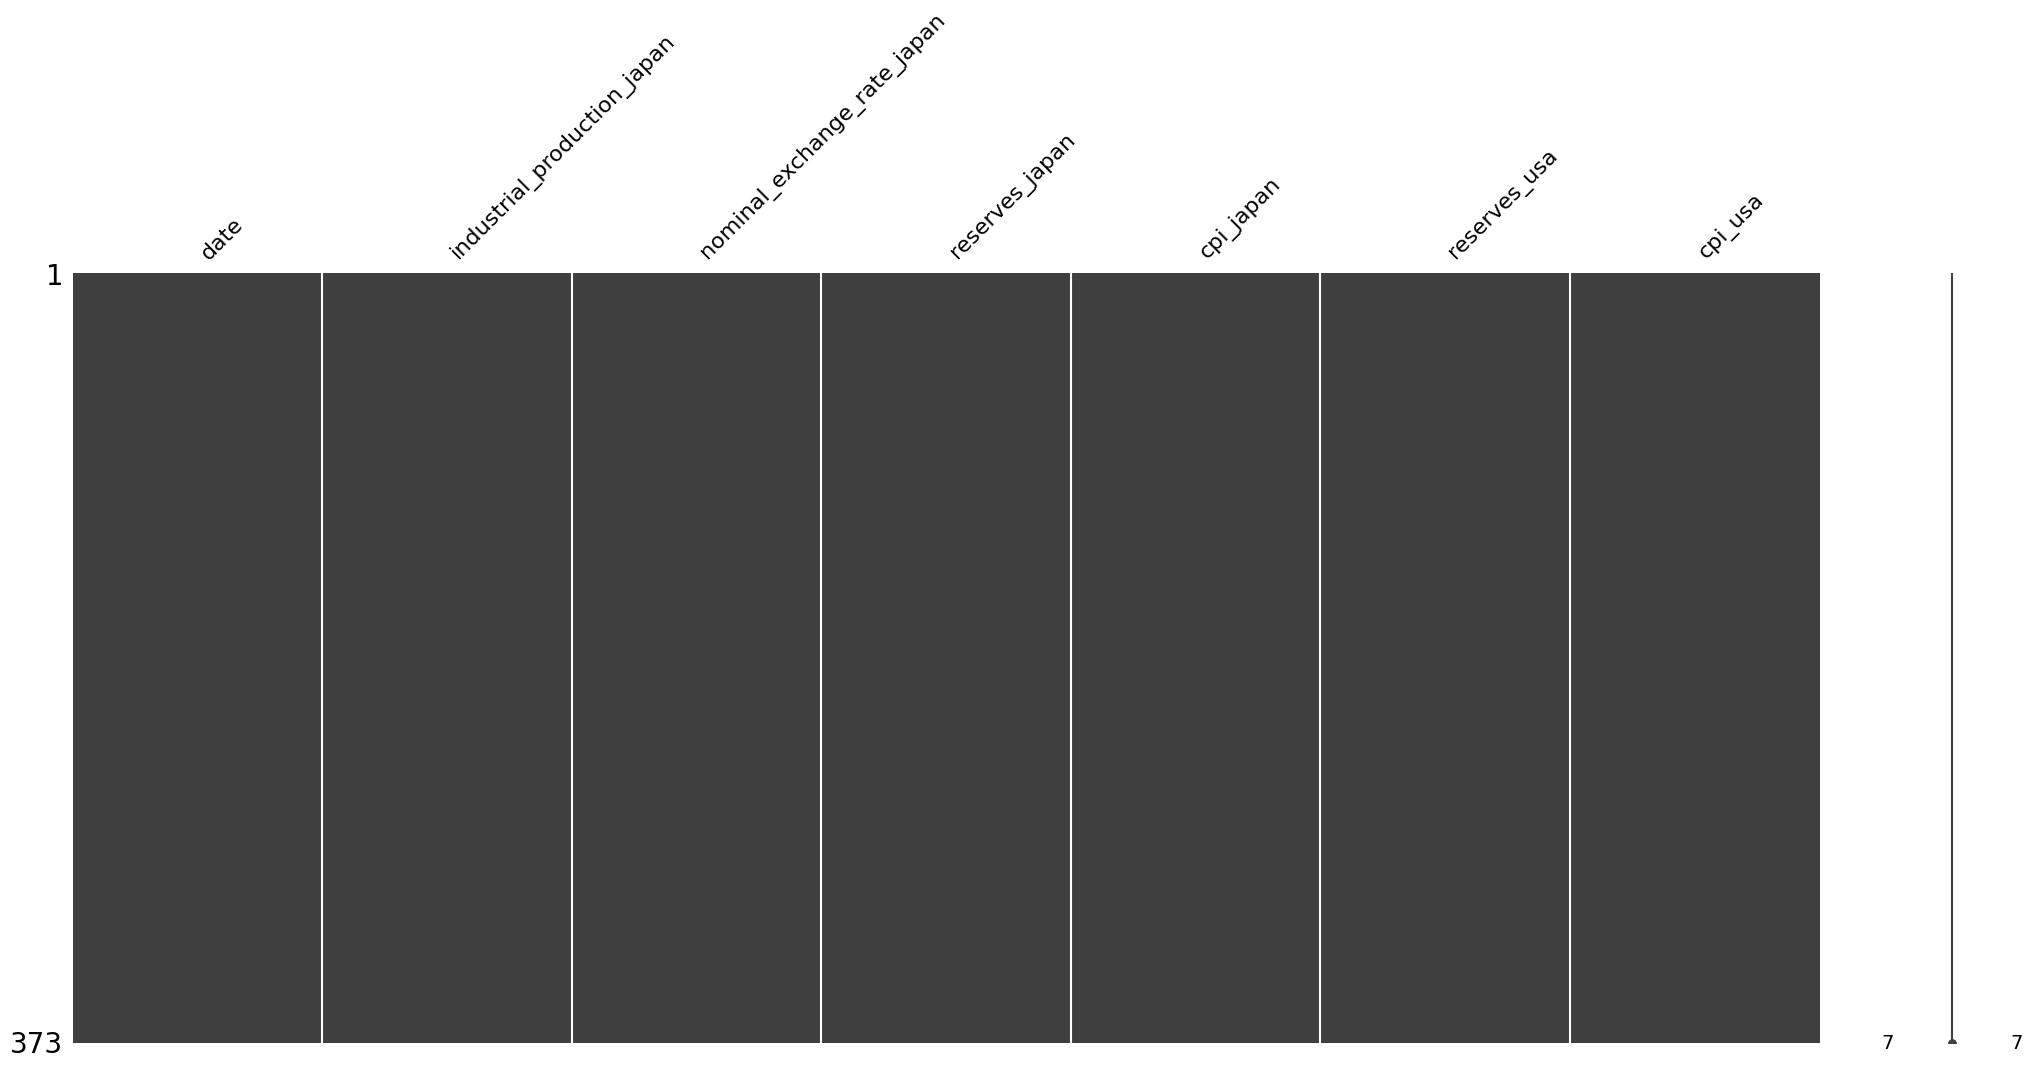

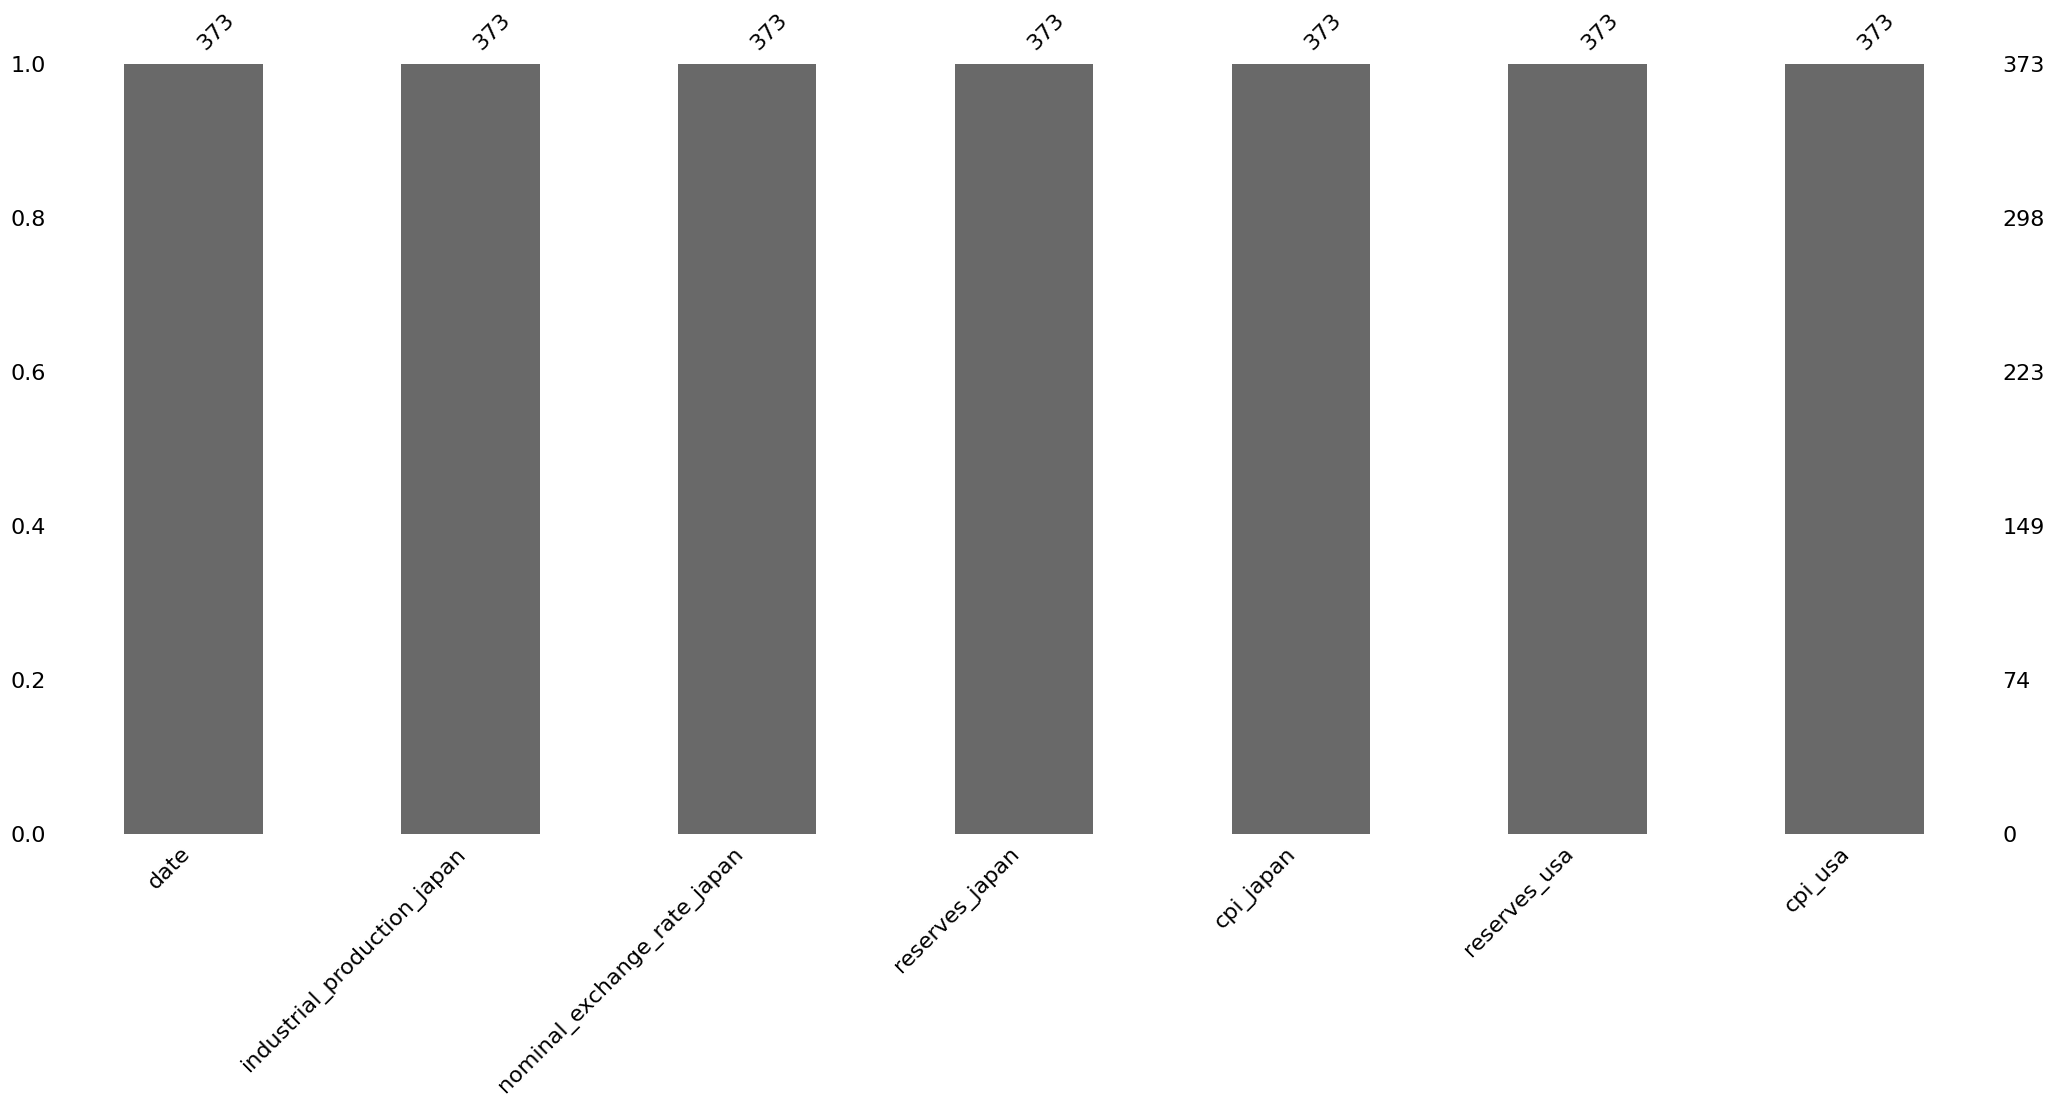

In [13]:
import missingno as msno
import sweetviz as sv
import matplotlib.pyplot as plt

# Generate missingness visualizations using missingno
plt.figure(figsize=(10, 6))
msno.matrix(merged_df)
plt.show()

plt.figure(figsize=(10, 6))
msno.bar(merged_df)
plt.show()



In [14]:
# Generate a Sweetviz report
report = sv.analyze(merged_df)
report.show_html("sweetviz_report.html")

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)


Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


No missing data yay!

In [15]:
# (i) Monthly growth in the nominal exchange rate
merged_df['nominal_ex_rate_growth_japan'] = merged_df['nominal_exchange_rate_japan'].pct_change() * 100

In [16]:
# (ii) Monthly growth in the real exchange rate
# Real Exchange Rate (RER) formula: RER = (Nominal Exchange Rate * CPI_US) / CPI_Japan
merged_df['real_exchange_rate_japan'] = (merged_df['nominal_exchange_rate_japan'] * merged_df['cpi_usa']) / merged_df['cpi_japan']
merged_df['real_ex_rate_growth_japan'] = merged_df['real_exchange_rate_japan'].pct_change() * 100

In [17]:
# (iii) Real exchange rate index (set Dec 1990 = 1)
base_rer = merged_df.loc[merged_df['date'] == '1990-12-01', 'real_exchange_rate_japan'].values[0]
merged_df['real_exchange_rate_index'] = merged_df['real_exchange_rate_japan'] / base_rer

In [18]:
merged_df['real_exchange_rate_index']

0      3.067764
1      3.021141
2      3.026904
3      3.036610
4      3.028450
         ...   
368    1.102347
369    1.040059
370    0.966059
371    0.965422
372    1.000000
Name: real_exchange_rate_index, Length: 373, dtype: float64

since we have to use growth rate i implemeneted this backward iteration!

In [19]:
last_index = merged_df.index[-1]

# Set the real exchange rate index for the last date to 1
merged_df.loc[last_index, 'real_exchange_rate_index_2'] = 1

# Compute the index backwards
for i in range(last_index - 1, -1, -1):  # Iterate backwards
    merged_df.loc[i, 'real_exchange_rate_index_2'] = (
        merged_df.loc[i + 1, 'real_exchange_rate_index_2'] / (1 + merged_df.loc[i + 1, 'real_ex_rate_growth_japan'] / 100)
    )


In [20]:
merged_df['real_exchange_rate_index_2']

0      3.067764
1      3.021141
2      3.026904
3      3.036610
4      3.028450
         ...   
368    1.102347
369    1.040059
370    0.966059
371    0.965422
372    1.000000
Name: real_exchange_rate_index_2, Length: 373, dtype: float64

In [21]:
# (iv) Monthly inflation rate for Japan
merged_df['inflation_rate_japan'] = merged_df['cpi_japan'].pct_change() * 100

In [22]:
# (v) Monthly growth in industrial production
merged_df['ind_prod_growth_japan'] = merged_df['industrial_production_japan'].pct_change() * 100

In [23]:
# (vi) Growth in industrial production versus 12 months ago
merged_df['ind_prod_growth_12m_japan'] = merged_df['industrial_production_japan'].pct_change(periods=12) * 100

In [24]:
# (vii) International reserves index for Japan (Jan 1960 = 100)
base_reserves_jp = merged_df.loc[merged_df['date'] == '1960-01-01', 'reserves_japan'].values[0]
merged_df['reserves_index_japan'] = (merged_df['reserves_japan'] / base_reserves_jp) * 100

Now for USAAAAAAAAAA

In [25]:
# (i) Monthly inflation rate for the US
merged_df['inflation_rate_usa'] = merged_df['cpi_usa'].pct_change() * 100

# (ii) International reserves index for the US (Jan 1960 = 100)
base_reserves_us = merged_df.loc[merged_df['date'] == '1960-01-01', 'reserves_usa'].values[0]
merged_df['reserves_index_usa'] = (merged_df['reserves_usa'] / base_reserves_us) * 100

In [26]:
merged_df

,date,industrial_production_japan,nominal_exchange_rate_japan,reserves_japan,cpi_japan,reserves_usa,cpi_usa,nominal_ex_rate_growth_japan,real_exchange_rate_japan,real_ex_rate_growth_japan,real_exchange_rate_index,real_exchange_rate_index_2,inflation_rate_japan,ind_prod_growth_japan,ind_prod_growth_12m_japan,reserves_index_japan,inflation_rate_usa,reserves_index_usa
0,1959-12-01,12.14,360.00,1446.26,18.52,21504.50,13.48,NaN,262.030238,NaN,3.067764,3.067764,NaN,NaN,NaN,99.515585,NaN,100.122916
1,1960-01-01,11.23,360.00,1453.30,18.75,21478.10,13.44,0.000000,258.048000,-1.519763,3.021141,3.021141,1.241901,-7.495881,NaN,100.000000,-0.296736,100.000000
2,1960-02-01,12.64,360.00,1446.33,18.77,21395.70,13.48,0.000000,258.540224,0.190749,3.026904,3.026904,0.106667,12.555654,NaN,99.520402,0.297619,99.616353
3,1960-03-01,13.63,360.00,1486.37,18.71,21344.70,13.48,0.000000,259.369321,0.320684,3.036610,3.036610,-0.319659,7.832278,NaN,102.275511,0.000000,99.378902
4,1960-04-01,12.72,360.00,1510.40,18.83,21278.00,13.53,0.000000,258.672331,-0.268725,3.028450,3.028450,0.641368,-6.676449,NaN,103.928989,0.370920,99.068353
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368,1990-08-01,97.70,147.42,77255.03,94.49,78908.84,60.35,-1.245981,94.155964,-0.770151,1.102347,1.102347,0.435799,-8.827921,4.805836,5315.834996,0.919732,367.392088
369,1990-09-01,106.07,138.99,77520.17,95.22,80024.17,60.86,-5.718356,88.835658,-5.650524,1.040059,1.040059,0.772569,8.567042,4.615840,5334.078993,0.845070,372.584959
370,1990-10-01,108.06,129.73,78465.27,96.25,82852.20,61.22,-6.662350,82.515019,-7.114980,0.966059,0.966059,1.081706,1.876120,7.747532,5399.110301,0.591522,385.751999
371,1990-11-01,106.47,129.08,78941.10,96.05,83059.40,61.36,-0.501041,82.460685,-0.065848,0.965422,0.965422,-0.207792,-1.471405,5.740391,5431.851648,0.228683,386.716702


In [27]:
# Show all rows and columns without truncation
pd.set_option("display.max_rows", None)  # Show all rows
pd.set_option("display.max_columns", None)  # Show all columns
pd.set_option("display.width", None)  # Expand width to fit the screen
pd.set_option("display.max_colwidth", None)  # Show full content of each cell

In [28]:
merged_df

,date,industrial_production_japan,nominal_exchange_rate_japan,reserves_japan,cpi_japan,reserves_usa,cpi_usa,nominal_ex_rate_growth_japan,real_exchange_rate_japan,real_ex_rate_growth_japan,real_exchange_rate_index,real_exchange_rate_index_2,inflation_rate_japan,ind_prod_growth_japan,ind_prod_growth_12m_japan,reserves_index_japan,inflation_rate_usa,reserves_index_usa
0,1959-12-01,12.14,360.00,1446.26,18.52,21504.50,13.48,NaN,262.030238,NaN,3.067764,3.067764,NaN,NaN,NaN,99.515585,NaN,100.122916
1,1960-01-01,11.23,360.00,1453.30,18.75,21478.10,13.44,0.000000,258.048000,-1.519763,3.021141,3.021141,1.241901,-7.495881,NaN,100.000000,-0.296736,100.000000
2,1960-02-01,12.64,360.00,1446.33,18.77,21395.70,13.48,0.000000,258.540224,0.190749,3.026904,3.026904,0.106667,12.555654,NaN,99.520402,0.297619,99.616353
3,1960-03-01,13.63,360.00,1486.37,18.71,21344.70,13.48,0.000000,259.369321,0.320684,3.036610,3.036610,-0.319659,7.832278,NaN,102.275511,0.000000,99.378902
4,1960-04-01,12.72,360.00,1510.40,18.83,21278.00,13.53,0.000000,258.672331,-0.268725,3.028450,3.028450,0.641368,-6.676449,NaN,103.928989,0.370920,99.068353
5,1960-05-01,12.80,360.00,1544.47,19.00,21234.30,13.53,0.000000,256.357895,-0.894737,3.001354,3.001354,0.902815,0.628931,NaN,106.273309,0.000000,98.864890
6,1960-06-01,12.80,360.00,1576.00,18.92,21169.80,13.57,0.000000,258.202960,0.719722,3.022955,3.022955,-0.421053,0.000000,NaN,108.442854,0.295639,98.564584
7,1960-07-01,12.97,360.00,1629.54,18.90,20999.40,13.57,0.000000,258.476190,0.105820,3.026154,3.026154,-0.105708,1.328125,NaN,112.126884,0.000000,97.771218
8,1960-08-01,12.80,360.00,1693.96,19.05,20803.40,13.57,0.000000,256.440945,-0.787402,3.002326,3.002326,0.793651,-1.310717,NaN,116.559554,0.000000,96.858661
9,1960-09-01,13.38,360.00,1782.99,19.21,20430.00,13.57,0.000000,254.305049,-0.832900,2.977320,2.977320,0.839895,4.531250,NaN,122.685612,0.000000,95.120146


# 1st try to identify outliers using IQR (from ST109)
 But way too many outliers are identified from this method, + economy will grow therefore most recent values in all columns are higher beyond a certain point will all exceed the IQR, therefore not a good way to identify outliers

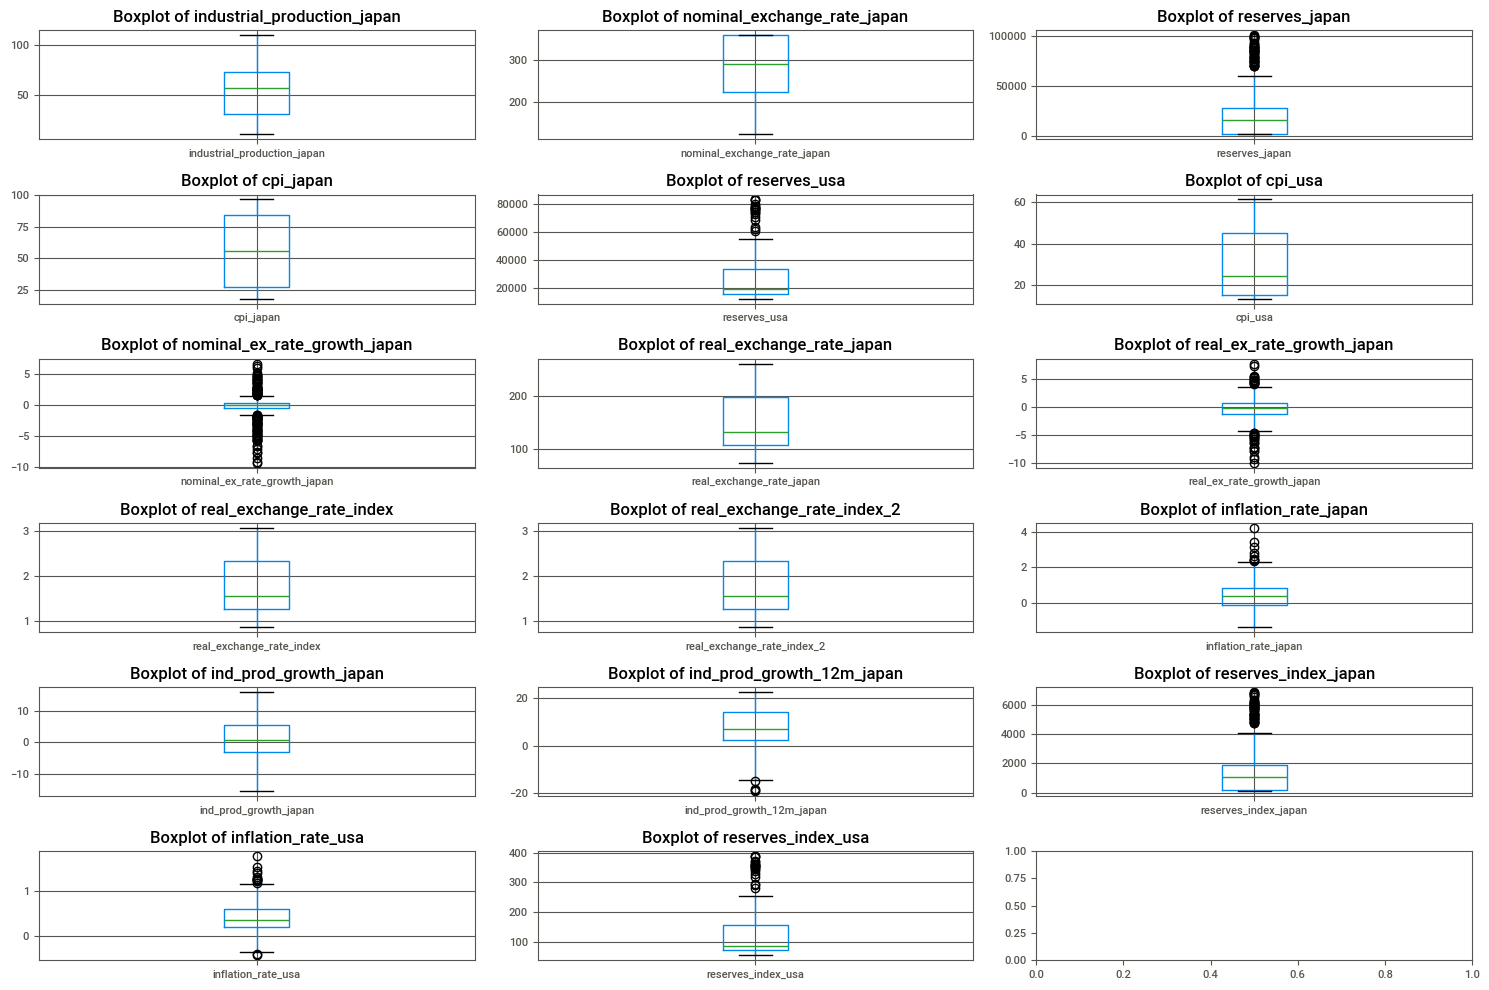

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Function to detect outliers using the IQR method
def detect_outliers_iqr(merged_df, columns):
    outliers = {}
    for col in columns:
        Q1 = merged_df[col].quantile(0.25)
        Q3 = merged_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers[col] = merged_df[(merged_df[col] < lower_bound) | (merged_df[col] > upper_bound)][['date', col]]

    return outliers

# Select only numeric columns for outlier detection
numeric_columns = merged_df.select_dtypes(include=[np.number]).columns

# Detect outliers
outliers_dict = detect_outliers_iqr(merged_df, numeric_columns)

# Plot boxplots for each numeric column to visualize outliers
fig, axes = plt.subplots(nrows=len(numeric_columns)//3 + 1, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    if i < len(axes):  # Ensure we don't exceed available axes
        merged_df.boxplot(column=[col], ax=axes[i])
        axes[i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()



In [30]:
outliers_df = pd.concat(outliers_dict.values(), keys=outliers_dict.keys()).reset_index(level=0).rename(columns={"level_0": "variable"})
outliers_df

,variable,date,industrial_production_japan,nominal_exchange_rate_japan,reserves_japan,cpi_japan,reserves_usa,cpi_usa,nominal_ex_rate_growth_japan,real_exchange_rate_japan,real_ex_rate_growth_japan,real_exchange_rate_index,real_exchange_rate_index_2,inflation_rate_japan,ind_prod_growth_japan,ind_prod_growth_12m_japan,reserves_index_japan,inflation_rate_usa,reserves_index_usa
328,reserves_japan,1987-04-01,NaN,NaN,69610.06,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
329,reserves_japan,1987-05-01,NaN,NaN,69882.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
330,reserves_japan,1987-06-01,NaN,NaN,70118.59,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
331,reserves_japan,1987-07-01,NaN,NaN,70603.92,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
332,reserves_japan,1987-08-01,NaN,NaN,71490.41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
333,reserves_japan,1987-09-01,NaN,NaN,72867.48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
334,reserves_japan,1987-10-01,NaN,NaN,73784.55,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
335,reserves_japan,1987-11-01,NaN,NaN,78800.16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
336,reserves_japan,1987-12-01,NaN,NaN,82175.87,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
337,reserves_japan,1988-01-01,NaN,NaN,84074.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Prepare the dataset for advanced outlier detection
numeric_cols = merged_df.select_dtypes(include=[np.number]).columns

# Standardize the data for better anomaly detection
scaler = StandardScaler()
scaled_data = scaler.fit_transform(merged_df[numeric_cols])

# Apply Isolation Forest (anomaly detection algorithm)
iso_forest = IsolationForest(n_estimators=100, contamination=0.02, random_state=42) #contamination selects for 0.02 (2%) of dataset as outliers
outlier_predictions = iso_forest.fit_predict(scaled_data)

# Mark outliers (-1 means outlier, 1 means normal)
merged_df['outlier_flag'] = outlier_predictions
merged_df['outlier_flag'] = merged_df['outlier_flag'].replace({1: 'Normal', -1: 'Outlier'})

# Extract detected outliers
outliers_df = merged_df[merged_df['outlier_flag'] == 'Outlier']

In [32]:
outliers_df

,date,industrial_production_japan,nominal_exchange_rate_japan,reserves_japan,cpi_japan,reserves_usa,cpi_usa,nominal_ex_rate_growth_japan,real_exchange_rate_japan,real_ex_rate_growth_japan,real_exchange_rate_index,real_exchange_rate_index_2,inflation_rate_japan,ind_prod_growth_japan,ind_prod_growth_12m_japan,reserves_index_japan,inflation_rate_usa,reserves_index_usa,outlier_flag
363,1990-03-01,109.35,153.08,74643.71,93.35,76303.03,59.02,5.187934,96.783949,5.410144,1.133115,1.133115,0.333190,13.421844,0.913621,5136.152893,0.545145,355.259683,Outlier
364,1990-04-01,100.99,158.47,74415.20,94.18,76283.21,59.11,3.521035,99.460201,2.765182,1.164447,1.164447,0.889127,-7.645176,2.945973,5120.429368,0.152491,355.167403,Outlier
366,1990-06-01,104.67,153.77,75263.41,94.28,77298.84,59.57,0.162845,97.158240,1.034931,1.137497,1.137497,-0.327730,7.134084,2.930475,5178.793780,0.540084,359.896080,Outlier
367,1990-07-01,107.16,149.28,76479.32,94.08,77906.29,59.80,-2.919945,94.886735,-2.337944,1.110903,1.110903,-0.212134,2.378905,6.637476,5262.459231,0.386100,362.724310,Outlier
369,1990-09-01,106.07,138.99,77520.17,95.22,80024.17,60.86,-5.718356,88.835658,-5.650524,1.040059,1.040059,0.772569,8.567042,4.615840,5334.078993,0.845070,372.584959,Outlier
370,1990-10-01,108.06,129.73,78465.27,96.25,82852.20,61.22,-6.662350,82.515019,-7.114980,0.966059,0.966059,1.081706,1.876120,7.747532,5399.110301,0.591522,385.751999,Outlier
371,1990-11-01,106.47,129.08,78941.10,96.05,83059.40,61.36,-0.501041,82.460685,-0.065848,0.965422,0.965422,-0.207792,-1.471405,5.740391,5431.851648,0.228683,386.716702,Outlier
372,1990-12-01,108.06,133.55,79706.96,95.94,83316.21,61.36,3.462969,85.414092,3.581594,1.000000,1.000000,-0.114524,1.493378,5.239579,5484.549646,0.000000,387.912385,Outlier


In [33]:
# Split columns for Japan and USA separately
japan_cols = [col for col in merged_df.columns if "_japan" in col]
usa_cols = [col for col in merged_df.columns if "_usa" in col]

# Function to plot time fluctuations for given columns
def plot_time_fluctuations(df, columns, country):
    num_cols = len(columns)
    fig, axes = plt.subplots(nrows=num_cols//3 + 1, ncols=3, figsize=(15, 5 * (num_cols//3 + 1)))
    axes = axes.flatten()

    for i, col in enumerate(columns):
        if i < len(axes):  # Ensure not exceeding available axes
            axes[i].plot(df['date'], df[col], label=col, color='b', linewidth=1)
            axes[i].set_title(f'{country} - {col} Over Time')
            axes[i].set_xlabel('Date')
            axes[i].set_ylabel(col)
            axes[i].tick_params(axis='x', rotation=45)
            axes[i].legend()

    plt.tight_layout()
    plt.show()


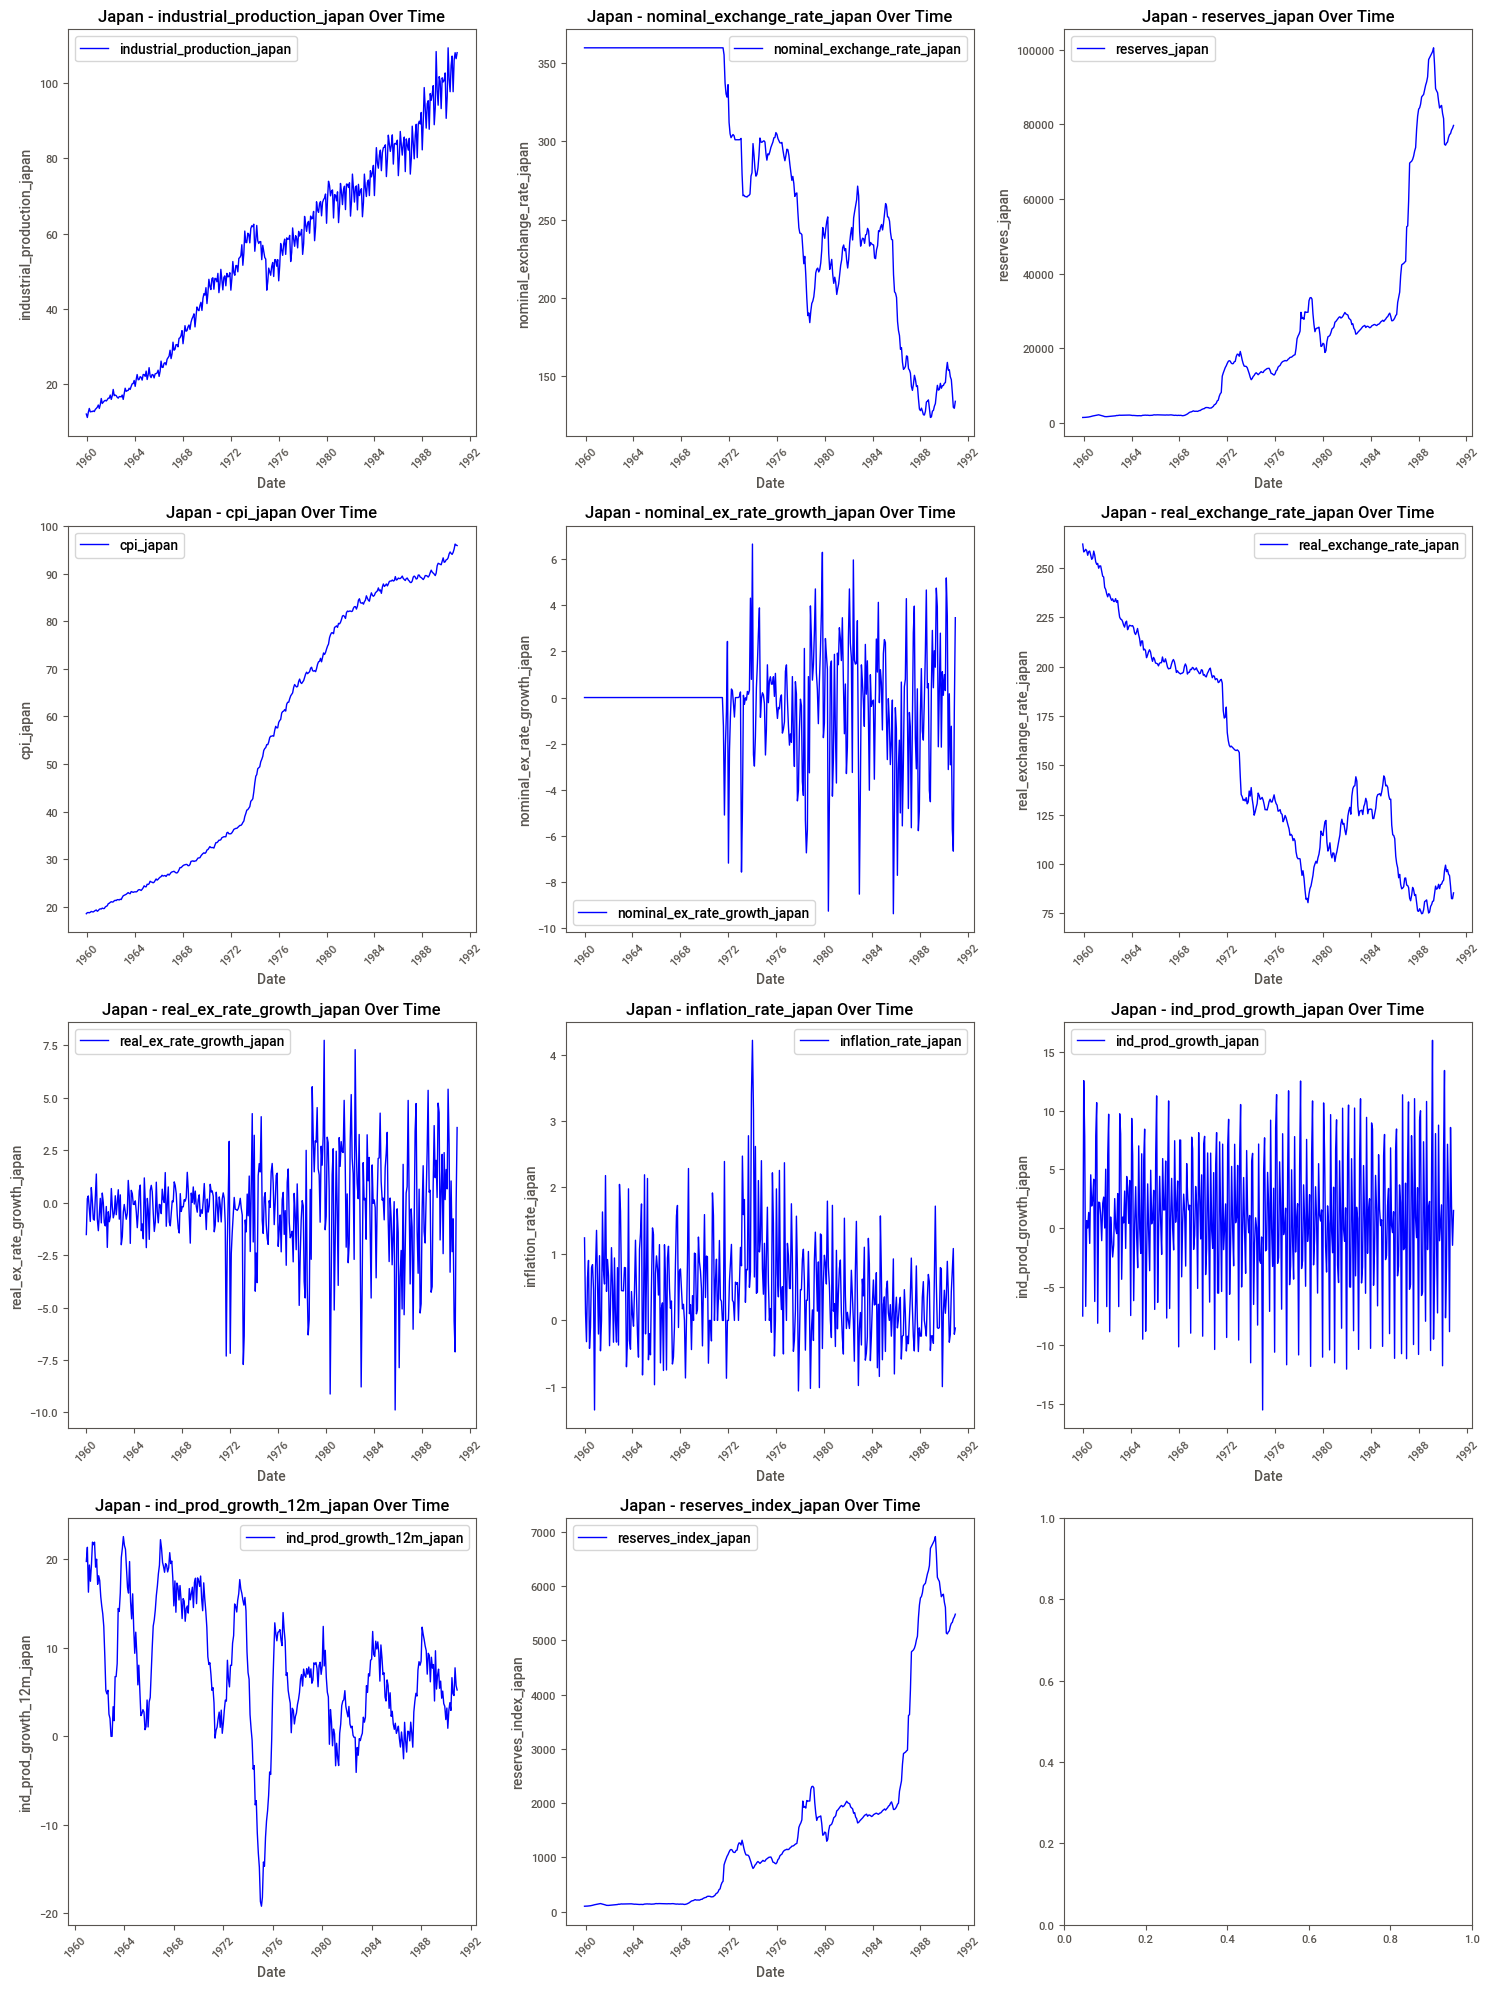

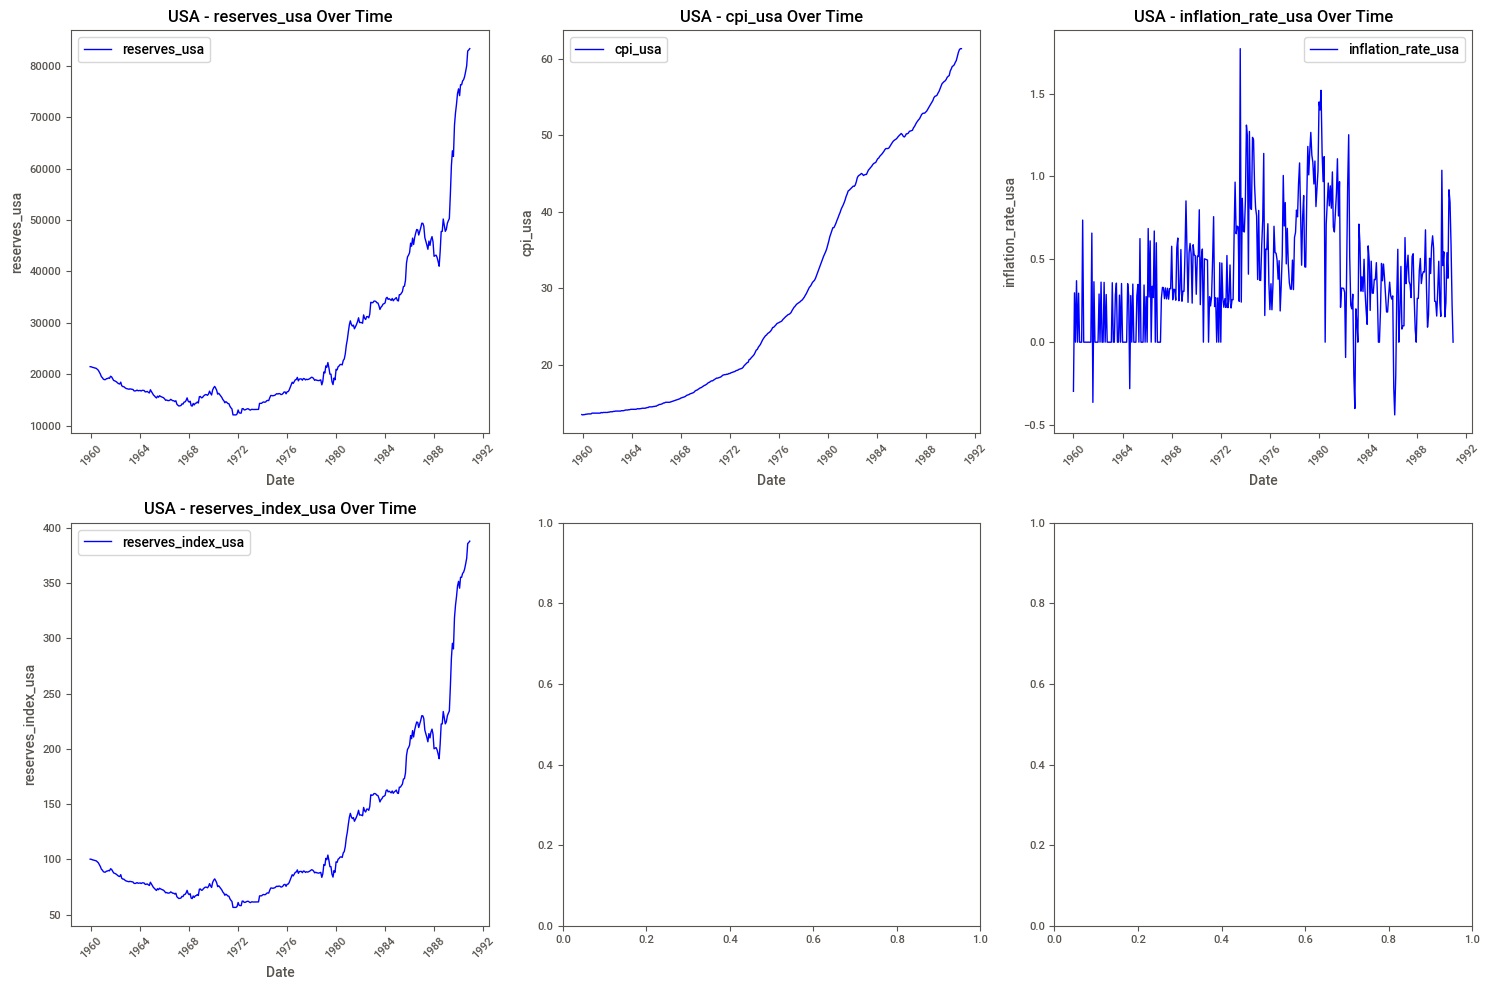

In [34]:
plot_time_fluctuations(merged_df, japan_cols, "Japan")
plot_time_fluctuations(merged_df, usa_cols, "USA")


<Figure size 1000x600 with 0 Axes>

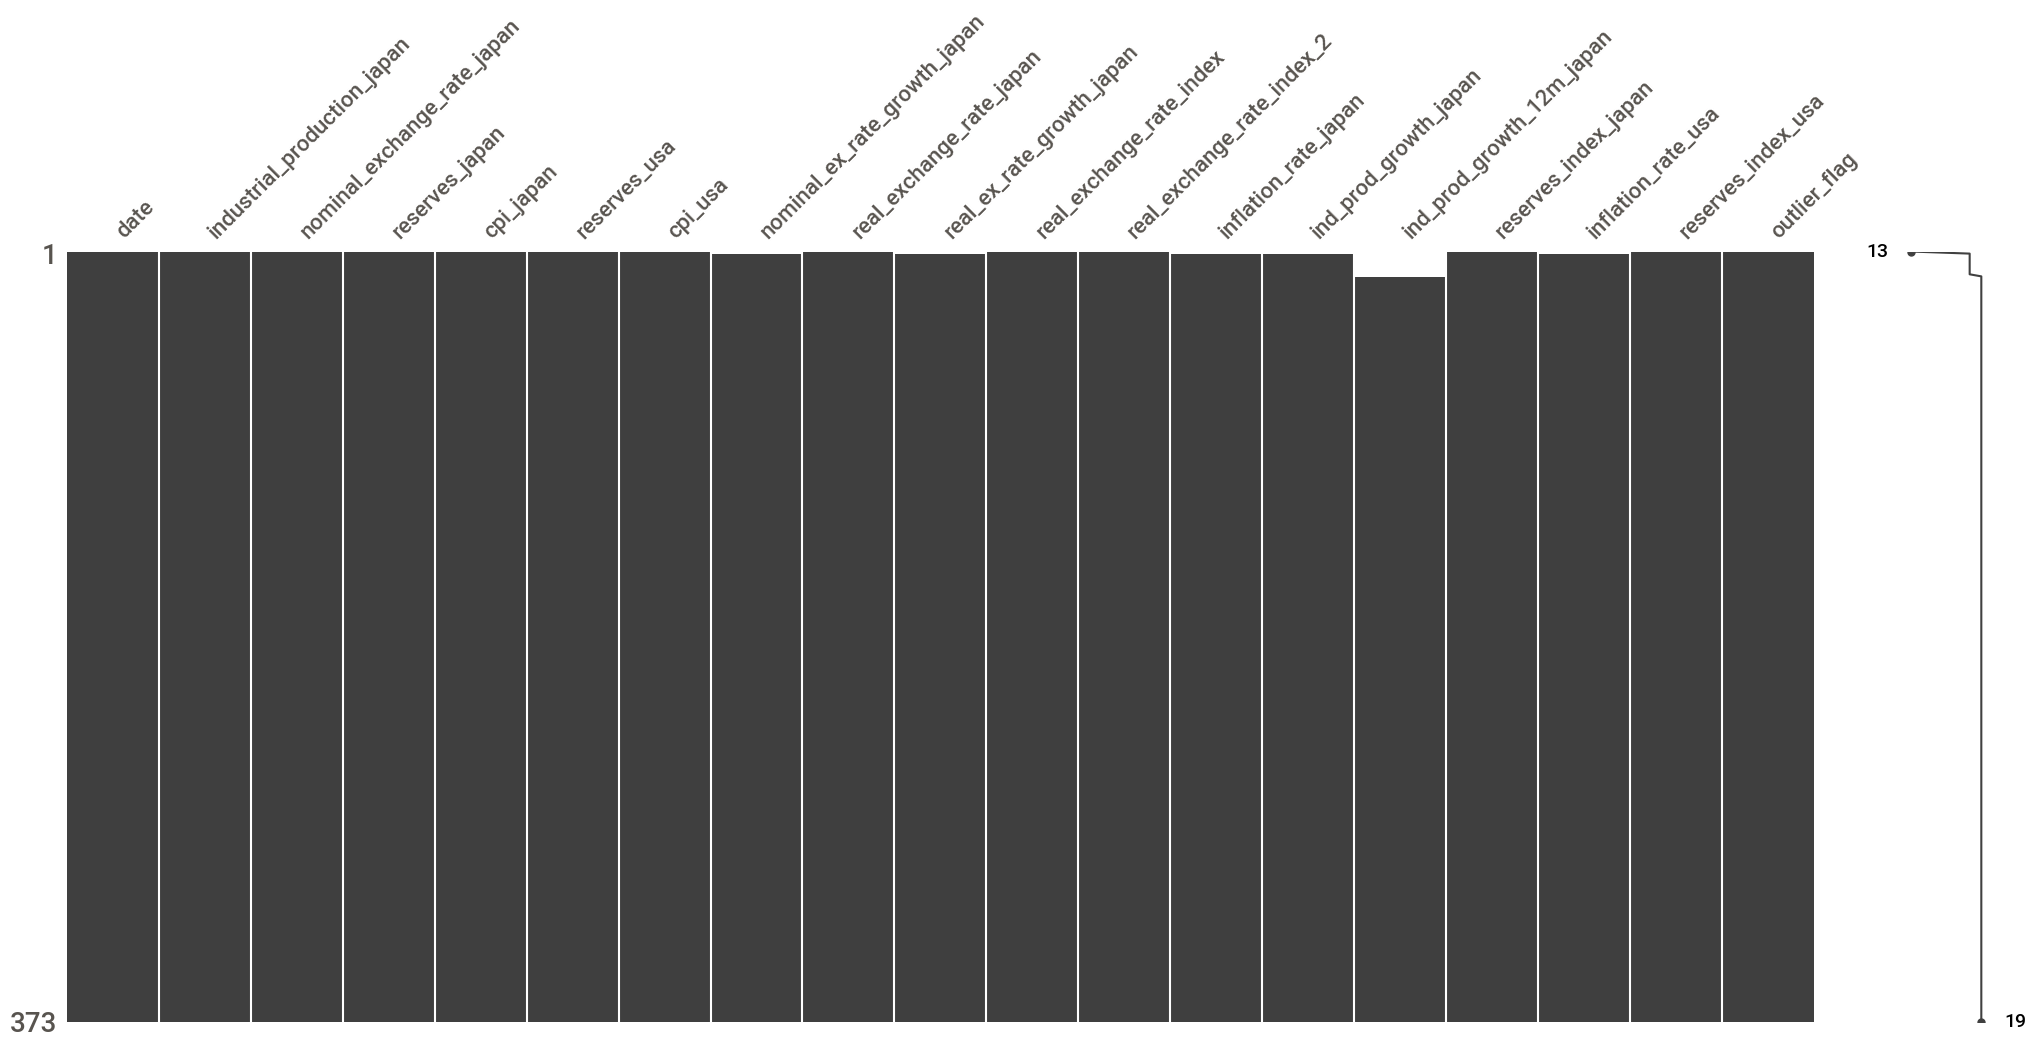

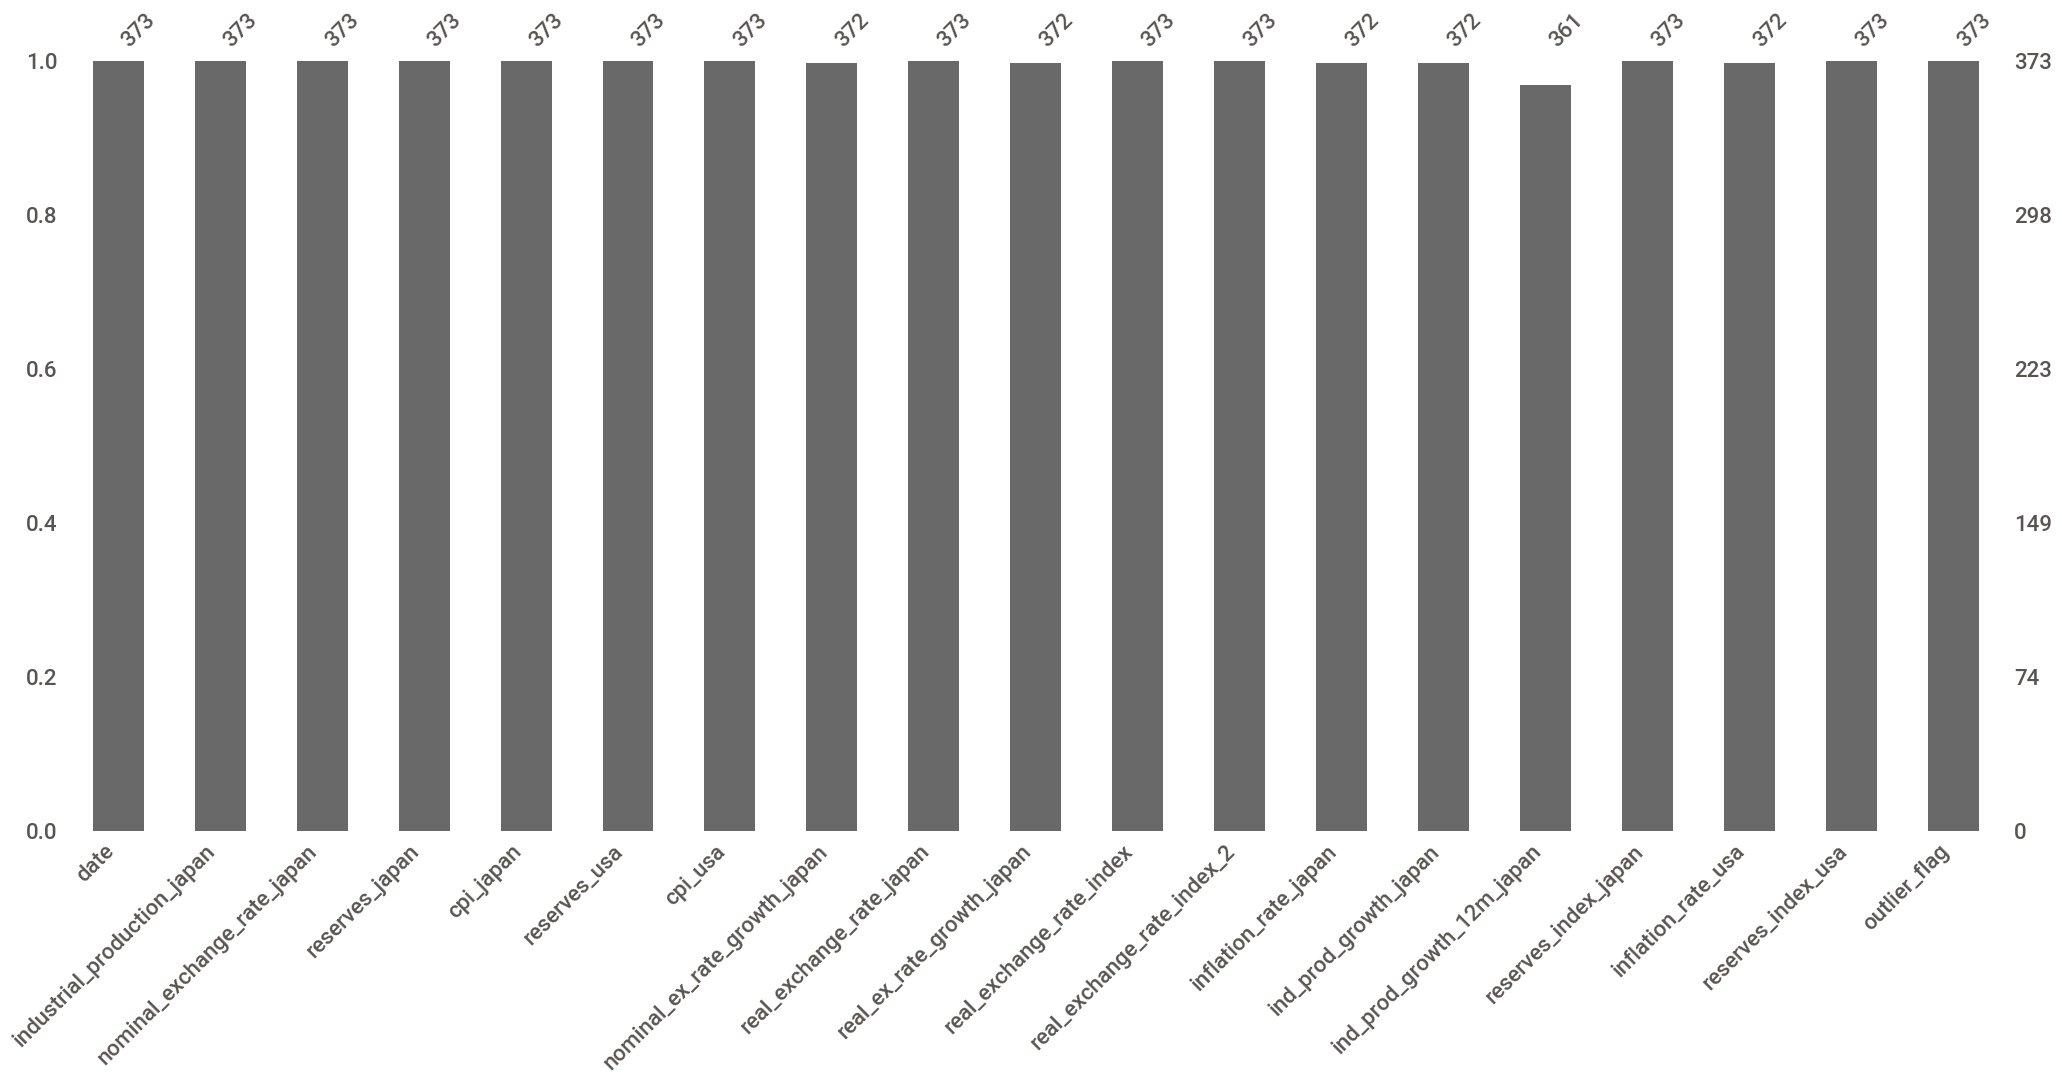

In [35]:
plt.figure(figsize=(10, 6))
msno.matrix(merged_df)
plt.show()

plt.figure(figsize=(10, 6))
msno.bar(merged_df)
plt.show()

The first 12 months of data do not have a previous year’s corresponding data to compare.
Since pct_change(periods=12) calculates growth compared to the same month a year ago, the first 12 months of data naturally result in NaN because there's no previous value to calculate the change. 


In [36]:
# Select only numeric columns for interpolation
numeric_cols = merged_df.select_dtypes(include=[np.number]).columns

# Apply interpolation only to numeric columns
merged_df[numeric_cols] = merged_df[numeric_cols].interpolate(method='linear')

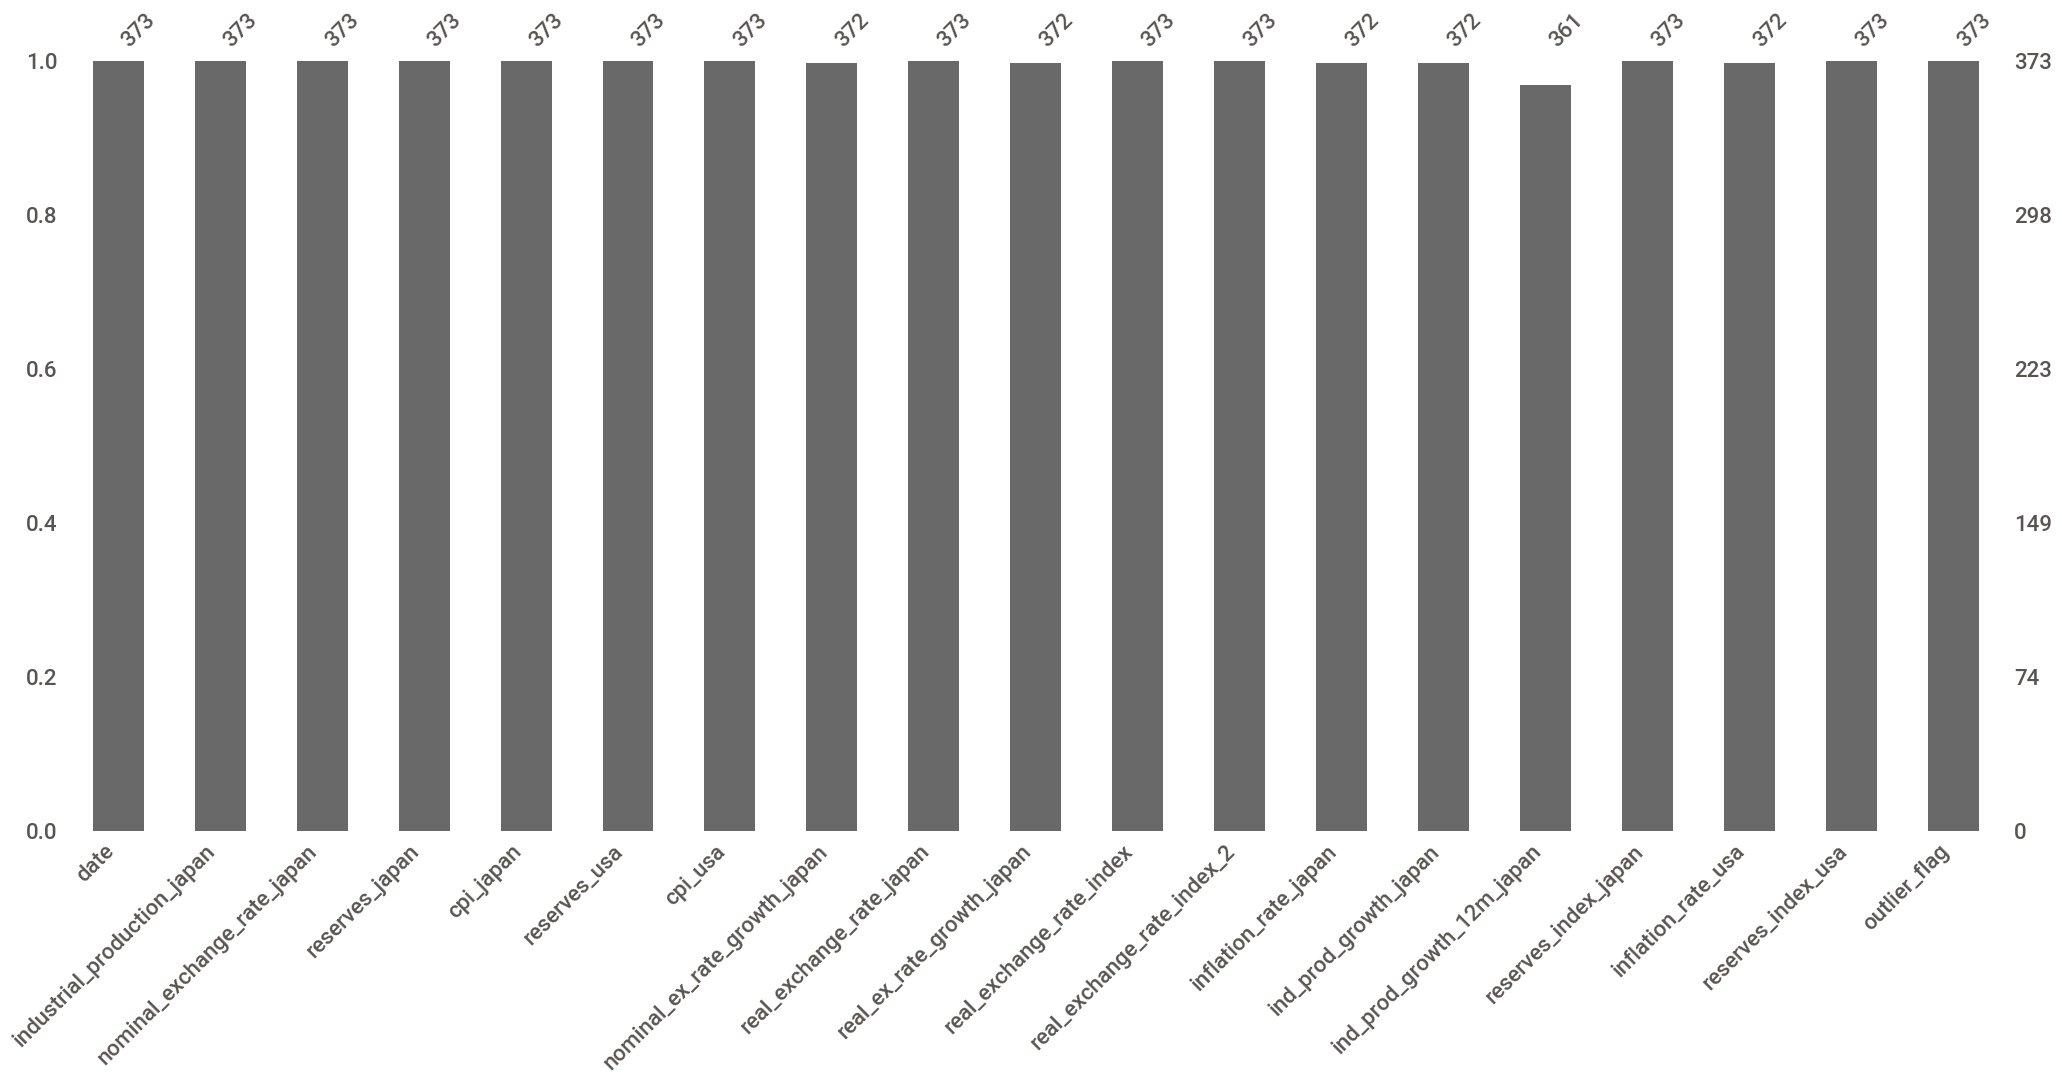

In [37]:
plt.figure(figsize=(10, 6))
msno.bar(merged_df)
plt.show()

Linear interpolation will not work either, no adjacent date available to 'interpolate' from! I will think abt this more but for now no biggie since its time series will not affect graphing too much!

as proven earlier and inspected again real exchange rate and real exchange rate 2 are the same thing so can just drop one of them and keep the other one (both have same math --> one uses growth rates one scales based on last row)

In [38]:
merged_df.drop('real_exchange_rate_index_2', axis=1, inplace=True)


In [39]:
merged_df.to_csv('merged.csv', index=False, encoding="utf-8")

In [52]:
# Dropping the first row of data (December 1959)
merged_df = merged_df[merged_df['date'] != '1959-12-01']
merged_df['difference_in_inflation_rates'] = merged_df['inflation_rate_japan'] - merged_df['inflation_rate_usa']
merged_df

,index,date,industrial_production_japan,nominal_exchange_rate_japan,reserves_japan,cpi_japan,reserves_usa,cpi_usa,nominal_ex_rate_growth_japan,real_exchange_rate_japan,real_ex_rate_growth_japan,real_exchange_rate_index,inflation_rate_japan,ind_prod_growth_japan,ind_prod_growth_12m_japan,reserves_index_japan,inflation_rate_usa,reserves_index_usa,outlier_flag,difference_in_inflation_rates
0,1,1960-01-01,11.23,360.00,1453.30,18.75,21478.10,13.44,0.000000,258.048000,-1.519763,3.021141,1.241901,-7.495881,NaN,100.000000,-0.296736,100.000000,Normal,1.538637
1,2,1960-02-01,12.64,360.00,1446.33,18.77,21395.70,13.48,0.000000,258.540224,0.190749,3.026904,0.106667,12.555654,NaN,99.520402,0.297619,99.616353,Normal,-0.190952
2,3,1960-03-01,13.63,360.00,1486.37,18.71,21344.70,13.48,0.000000,259.369321,0.320684,3.036610,-0.319659,7.832278,NaN,102.275511,0.000000,99.378902,Normal,-0.319659
3,4,1960-04-01,12.72,360.00,1510.40,18.83,21278.00,13.53,0.000000,258.672331,-0.268725,3.028450,0.641368,-6.676449,NaN,103.928989,0.370920,99.068353,Normal,0.270448
4,5,1960-05-01,12.80,360.00,1544.47,19.00,21234.30,13.53,0.000000,256.357895,-0.894737,3.001354,0.902815,0.628931,NaN,106.273309,0.000000,98.864890,Normal,0.902815
5,6,1960-06-01,12.80,360.00,1576.00,18.92,21169.80,13.57,0.000000,258.202960,0.719722,3.022955,-0.421053,0.000000,NaN,108.442854,0.295639,98.564584,Normal,-0.716692
6,7,1960-07-01,12.97,360.00,1629.54,18.90,20999.40,13.57,0.000000,258.476190,0.105820,3.026154,-0.105708,1.328125,NaN,112.126884,0.000000,97.771218,Normal,-0.105708
7,8,1960-08-01,12.80,360.00,1693.96,19.05,20803.40,13.57,0.000000,256.440945,-0.787402,3.002326,0.793651,-1.310717,NaN,116.559554,0.000000,96.858661,Normal,0.793651
8,9,1960-09-01,13.38,360.00,1782.99,19.21,20430.00,13.57,0.000000,254.305049,-0.832900,2.977320,0.839895,4.531250,NaN,122.685612,0.000000,95.120146,Normal,0.839895
9,10,1960-10-01,13.63,360.00,1842.03,19.30,20068.20,13.67,0.000000,254.984456,0.267162,2.985274,0.468506,1.868460,NaN,126.748091,0.736920,93.435639,Normal,-0.268414


## 5.2.1 Exchange Rate and International Reserves Graph 
Monthly Growth in the Nominal Exchange Rate, Level of the Nominal Exchange Rate, Monthly Growth in the Real Exchange Rate, Real Exchange Rate Index

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.style as style 
import numpy as np
from matplotlib.patches import FancyBboxPatch
merged_df.reset_index(inplace = True)

In [ ]:
graph_1_df = merged_df[['date']].copy()
for col in ['nominal_exchange_rate_japan', 'nominal_ex_rate_growth_japan', 'real_exchange_rate_index', 'real_ex_rate_growth_japan']:
    graph_1_df[f'{col}_norm'] = (np.array(merged_df[col]) - min(merged_df[col])) / (max(merged_df[col]) - min(merged_df[col]))
graph_1_df[['reserves_index_japan', 'reserves_index_usa']] = merged_df[['reserves_index_japan', 'reserves_index_usa']]
print("Graph 1 DF")
display(graph_1_df)

graph_2_df = merged_df[['date']].copy()
for col in ['inflation_rate_japan', 'inflation_rate_usa', 'ind_prod_growth_japan', 'ind_prod_growth_12m_japan', 'difference_in_inflation_rates']:
    graph_2_df[col] = merged_df[col]
print("\n Graph 2 DF")
display(graph_2_df)


Graph 1 DF


,date,nominal_exchange_rate_japan_norm,nominal_ex_rate_growth_japan_norm,real_exchange_rate_index_norm,real_ex_rate_growth_japan_norm,reserves_index_japan,reserves_index_usa
0,1960-01-01,1.000000,0.584828,0.992839,0.474567,100.000000,100.000000
1,1960-02-01,1.000000,0.584828,0.995507,0.571626,99.520402,99.616353
2,1960-03-01,1.000000,0.584828,1.000000,0.578999,102.275511,99.378902
3,1960-04-01,1.000000,0.584828,0.996223,0.545554,103.928989,99.068353
4,1960-05-01,1.000000,0.584828,0.983679,0.510032,106.273309,98.864890
5,1960-06-01,1.000000,0.584828,0.993679,0.601641,108.442854,98.564584
6,1960-07-01,1.000000,0.584828,0.995159,0.566807,112.126884,97.771218
7,1960-08-01,1.000000,0.584828,0.984129,0.516123,116.559554,96.858661
8,1960-09-01,1.000000,0.584828,0.972553,0.513541,122.685612,95.120146
9,1960-10-01,1.000000,0.584828,0.976235,0.575962,126.748091,93.435639



 Graph 2 DF


,date,inflation_rate_japan,inflation_rate_usa,ind_prod_growth_japan,ind_prod_growth_12m_japan,difference_in_inflation_rates
0,1960-01-01,1.241901,-0.296736,-7.495881,NaN,1.538637
1,1960-02-01,0.106667,0.297619,12.555654,NaN,-0.190952
2,1960-03-01,-0.319659,0.000000,7.832278,NaN,-0.319659
3,1960-04-01,0.641368,0.370920,-6.676449,NaN,0.270448
4,1960-05-01,0.902815,0.000000,0.628931,NaN,0.902815
5,1960-06-01,-0.421053,0.295639,0.000000,NaN,-0.716692
6,1960-07-01,-0.105708,0.000000,1.328125,NaN,-0.105708
7,1960-08-01,0.793651,0.000000,-1.310717,NaN,0.793651
8,1960-09-01,0.839895,0.000000,4.531250,NaN,0.839895
9,1960-10-01,0.468506,0.736920,1.868460,NaN,-0.268414


In [43]:
def plot_exchange_rate_graphs(graph_1_df):
    # Ensure that the 'date' column is in datetime format
    graph_1_df['date'] = pd.to_datetime(graph_1_df['date'])
    
    # Plot
    fig, ax1 = plt.subplots(figsize=(14, 6))  # Increase figure width
    
    # Plot Nominal Exchange Rate Level
    sns.lineplot(x=graph_1_df['date'], y=graph_1_df['nominal_exchange_rate_japan_norm'], ax=ax1, label='Nominal Exchange Rate', color='blue')
    
    # Plot Monthly Growth in Nominal Exchange Rate (secondary axis)
    ax2 = ax1.twinx()
    sns.lineplot(x=graph_1_df['date'], y=graph_1_df['nominal_ex_rate_growth_japan_norm'], ax=ax2, label='Nominal Exchange Rate Growth', color='red', linestyle='dashed')
    
    # Plot Real Exchange Rate Index
    sns.lineplot(x=graph_1_df['date'], y=graph_1_df['real_exchange_rate_index_norm'], ax=ax1, label='Real Exchange Rate Index', color='green')
    
    # Plot Monthly Growth in Real Exchange Rate (secondary axis)
    sns.lineplot(x=graph_1_df['date'], y=graph_1_df['real_ex_rate_growth_japan_norm'], ax=ax2, label='Real Exchange Rate Growth', color='purple', linestyle='dotted')
    
    # Labels
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Exchange Rate / Index')
    ax2.set_ylabel('Monthly Growth')
    
    # Create custom ticks for every 5 years from 1960 to 1990
    regular_ticks = [pd.to_datetime(f"{year}-01-01") for year in range(1960, 1995, 5)]
    
    # Add August 1971 and March 1973 ticks
    august_1971 = pd.to_datetime('1971-08-01')
    march_1973 = pd.to_datetime('1973-03-01')
    
    # Combine all ticks and sort them
    all_ticks = regular_ticks + [august_1971, march_1973]
    all_ticks.sort()
    
    # Convert datetime ticks to matplotlib's numerical format
    tick_nums = [mdates.date2num(tick) for tick in all_ticks]
    
    # Set the ticks
    ax1.set_xticks(tick_nums)
    
    # Create corresponding labels
    tick_labels = []
    for tick in all_ticks:
        if tick.month == 8 and tick.year == 1971:
            tick_labels.append('August 1971')
        elif tick.month == 3 and tick.year == 1973:
            tick_labels.append('March 1973')
        else:
            tick_labels.append(f'January {tick.year}')
    
    # Set the tick labels
    ax1.set_xticklabels(tick_labels, rotation=45)
    
    # Add vertical lines at August 1971 and March 1973
    ax1.axvline(x=mdates.date2num(august_1971), color='black', linestyle='--', linewidth=2.5, alpha=0.5)
    ax1.axvline(x=mdates.date2num(march_1973), color='black', linestyle='--', linewidth=2.5, alpha=0.5)
    
    # Add annotation for August 1971
    ax1.annotate('Japan Leaving Bretton Woods', 
                xy=(mdates.date2num(august_1971), 0.1),  # Arrow tip position
                xytext=(mdates.date2num(pd.to_datetime('1961-01-01')), 0.1),  # Text position
                xycoords=('data', 'axes fraction'),
                textcoords=('data', 'axes fraction'),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='black'),
                fontsize=12, 
                fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.5", fc="lightgrey", ec="black", alpha=0.7))
    
    # Add annotation for March 1973
    ax1.annotate('Floating Exchange Rate System', 
                xy=(mdates.date2num(march_1973), 0.2),  # Arrow tip position (slightly higher)
                xytext=(mdates.date2num(pd.to_datetime('1961-01-01')), 0.2),  # Text position (above first annotation)
                xycoords=('data', 'axes fraction'),
                textcoords=('data', 'axes fraction'),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='black'),
                fontsize=12, 
                fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.5", fc="lightgrey", ec="black", alpha=0.7))
    
    # Adjust x-axis limits if necessary
    ax1.set_xlim(pd.to_datetime('1960-01-01'), pd.to_datetime('1990-01-01'))
    
    # Legends
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    
    plt.title('Exchange Rate and International Reserve Graphs')
    plt.tight_layout()  # Adjust the layout to prevent overlap
    plt.show()

In [44]:
graph_1_df['reserves_index_japan_log'] = np.log10(graph_1_df['reserves_index_japan'])
graph_1_df['reserves_index_usa_log'] = np.log10(graph_1_df['reserves_index_usa'])

def plot_reserves_graph(graph_1_df):
    # Ensure that the 'date' column is in datetime format
    graph_1_df['date'] = pd.to_datetime(graph_1_df['date'])
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 6))  # Increase figure width
    
    # Plot International Reserves for Japan and USA
    sns.lineplot(x=graph_1_df['date'], y=graph_1_df['reserves_index_japan_log'], ax=ax, 
                 label='Log (Base 10) International Reserves Index (Japan)', color='blue')
    sns.lineplot(x=graph_1_df['date'], y=graph_1_df['reserves_index_usa_log'], ax=ax, 
                 label='Log (Base 10) International Reserves Index (USA)', color='red')
    
    # Labels
    ax.set_xlabel('Date')
    ax.set_ylabel('Log (Base 10) International Reserves Index')
    
    # Create custom ticks for every 5 years from 1960 to 1990
    regular_ticks = [pd.to_datetime(f"{year}-01-01") for year in range(1960, 1995, 5)]
    
    # Add August 1971 and March 1973 ticks
    august_1971 = pd.to_datetime('1971-08-01')
    march_1973 = pd.to_datetime('1973-03-01')
    
    # Combine all ticks and sort them
    all_ticks = regular_ticks + [august_1971, march_1973]
    all_ticks.sort()
    
    # Convert datetime ticks to matplotlib's numerical format
    tick_nums = [mdates.date2num(tick) for tick in all_ticks]
    
    # Set the ticks
    ax.set_xticks(tick_nums)
    
    # Create corresponding labels
    tick_labels = []
    for tick in all_ticks:
        if tick.month == 8 and tick.year == 1971:
            tick_labels.append('August 1971')
        elif tick.month == 3 and tick.year == 1973:
            tick_labels.append('March 1973')
        else:
            tick_labels.append(f'January {tick.year}')
    
    # Set the tick labels
    ax.set_xticklabels(tick_labels, rotation=45)
    
    # Add vertical lines at August 1971 and March 1973
    ax.axvline(x=mdates.date2num(august_1971), color='black', linestyle='--', linewidth=2.5, alpha=0.5)
    ax.axvline(x=mdates.date2num(march_1973), color='black', linestyle='--', linewidth=2.5, alpha=0.5)
    
    # Get y-axis limits to position annotations better
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    
    # Add annotation for August 1971 - Higher position (0.4 instead of 0.1)
    ax.annotate('Japan Leaving Bretton Woods', 
                xy=(mdates.date2num(august_1971), 0.4),  # Arrow tip position higher
                xytext=(mdates.date2num(pd.to_datetime('1961-01-01')), 0.4),  # Text position higher
                xycoords=('data', 'axes fraction'),
                textcoords=('data', 'axes fraction'),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='black'),
                fontsize=12, 
                fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.5", fc="lightgrey", ec="black", alpha=0.7))
    
    # Add annotation for March 1973 - Higher position (0.5 instead of 0.2)
    ax.annotate('Floating Exchange Rate System', 
                xy=(mdates.date2num(march_1973), 0.5),  # Arrow tip position higher
                xytext=(mdates.date2num(pd.to_datetime('1961-01-01')), 0.5),  # Text position higher
                xycoords=('data', 'axes fraction'),
                textcoords=('data', 'axes fraction'),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='black'),
                fontsize=12, 
                fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.5", fc="lightgrey", ec="black", alpha=0.7))
    
    # Adjust x-axis limits if necessary
    ax.set_xlim(pd.to_datetime('1960-01-01'), pd.to_datetime('1990-01-01'))
    
    # Add gridlines
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)
    
    # Legend
    ax.legend(loc='upper left')
    
    plt.title('International Reserves Index for Japan and USA (January 1960 - August 1971)')
    plt.tight_layout()  # Adjust the layout to prevent overlap
    plt.show()

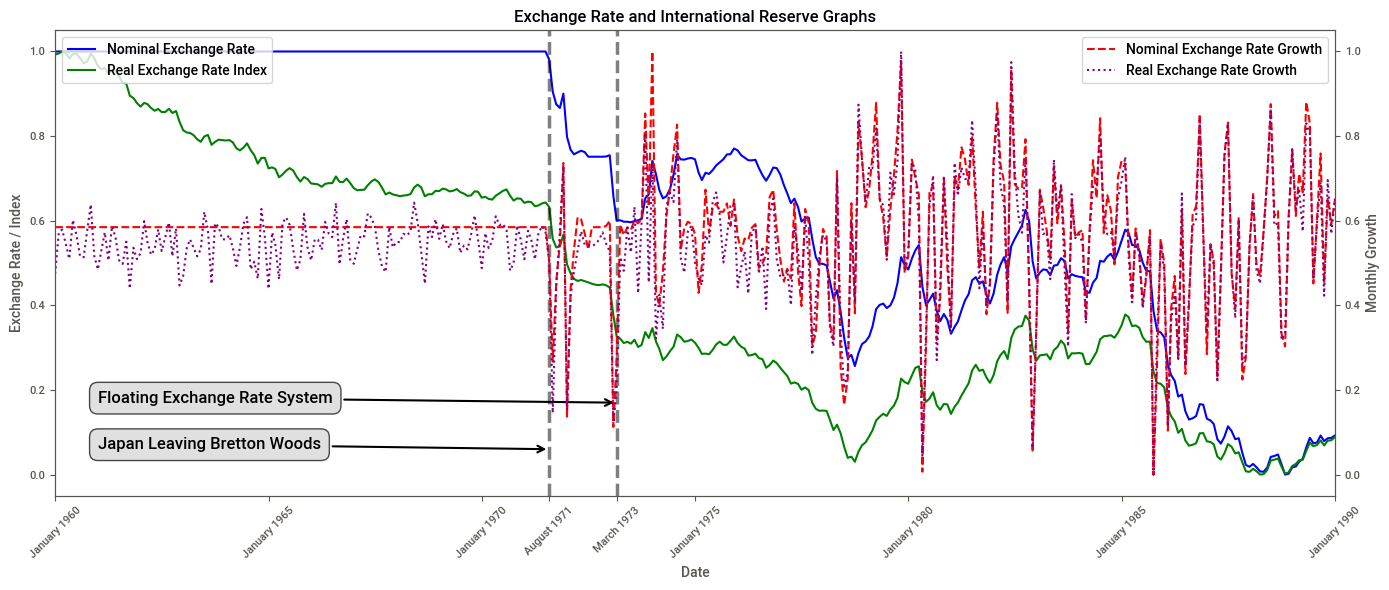

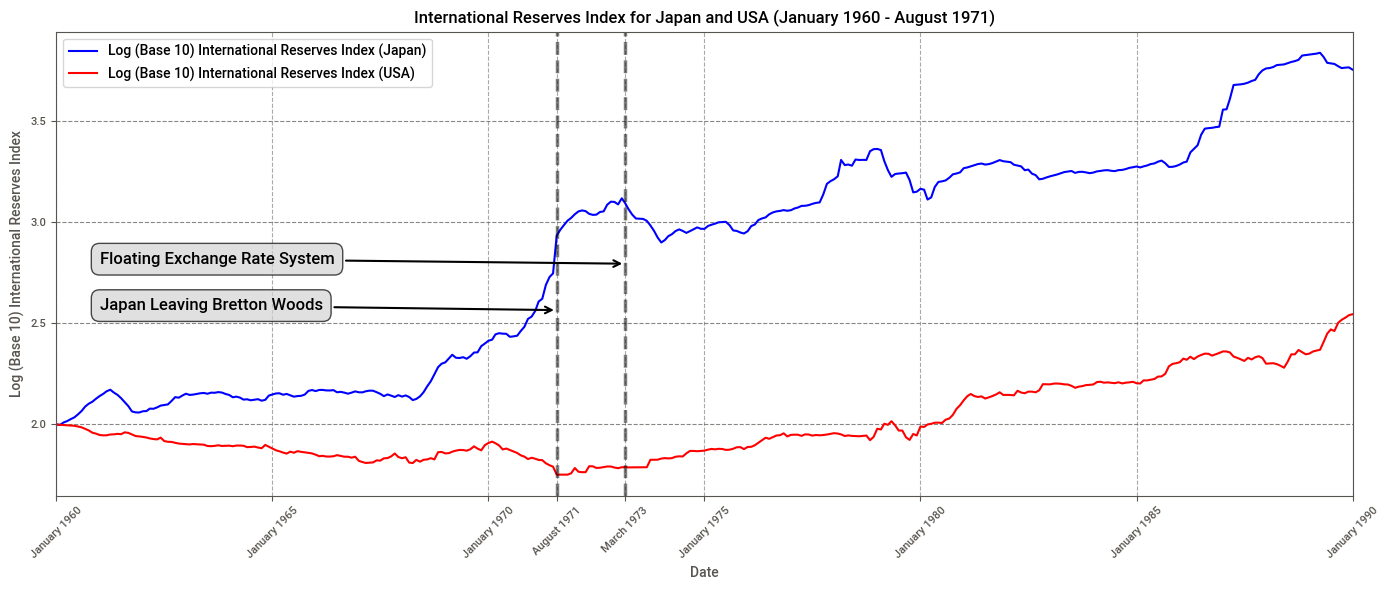

In [45]:
plot_exchange_rate_graphs(graph_1_df)
plot_reserves_graph(graph_1_df)

## 5.2.2 Inflation and Industrial Production Graphs
Plot the following time series graphs, presenting the inflation graphs together and the industrial production graphs together:
- Monthly inflation.
- The difference between monthly inflation in your country versus the US.
- The monthly growth in industrial production.
- The growth in industrial production versus 12 months ago.

Why are your results for the monthly versus 12 monthly growth in industrial production so different?
Which measure is more useful?


In [46]:
print(graph_2_df.columns)

Index(['date', 'inflation_rate_japan', 'inflation_rate_usa',
       'ind_prod_growth_japan', 'ind_prod_growth_12m_japan',
       'difference_in_inflation_rates'],
      dtype='object')


In [149]:
def plot_inflation_graph(graph_2_df):
    # Ensure that the 'date' column is in datetime format
    graph_2_df['date'] = pd.to_datetime(graph_2_df['date'])
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 6))  # Increase figure width
    
    # Plot International Reserves for Japan and USA
    sns.lineplot(x=graph_2_df['date'], y=graph_2_df['inflation_rate_japan'], ax=ax, 
                 label='Inflation Rate (Japan)', color='#E69F00')
    sns.lineplot(x=graph_2_df['date'], y=graph_2_df['difference_in_inflation_rates'], ax=ax, 
                 label='Difference in Inflation Rates (Japan - USA)', color='#0072B2', alpha = 0.7)
    
    # Labels
    ax.set_xlabel('Date')
    ax.set_ylabel('Inflation Rate')
    
    # Create custom ticks for every 5 years from 1960 to 1990
    regular_ticks = [pd.to_datetime(f"{year}-01-01") for year in range(1960, 1995, 5)]
    
    # Add August 1971 and March 1973 ticks
    august_1971 = pd.to_datetime('1971-08-01')
    march_1973 = pd.to_datetime('1973-03-01')
    
    # Combine all ticks and sort them
    all_ticks = regular_ticks + [august_1971, march_1973]
    all_ticks.sort()
    
    # Convert datetime ticks to matplotlib's numerical format
    tick_nums = [mdates.date2num(tick) for tick in all_ticks]
    
    # Set the ticks
    ax.set_xticks(tick_nums)
    
    # Create corresponding labels
    tick_labels = []
    for tick in all_ticks:
        if tick.month == 8 and tick.year == 1971:
            tick_labels.append('August 1971')
        elif tick.month == 3 and tick.year == 1973:
            tick_labels.append('March 1973')
        else:
            tick_labels.append(f'January {tick.year}')
    
    # Set the tick labels
    ax.set_xticklabels(tick_labels, rotation=45)
    
    # Add vertical lines at August 1971 and March 1973
    ax.axvline(x=mdates.date2num(august_1971), color='black', linestyle='--', linewidth=2.5, alpha=0.5)
    ax.axvline(x=mdates.date2num(march_1973), color='black', linestyle='--', linewidth=2.5, alpha=0.5)
    
    # Get y-axis limits to position annotations better
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    
    # Add annotation for August 1971 - Higher position (0.7 instead of 0.4)
    ax.annotate('Japan Leaving Bretton Woods', 
                xy=(mdates.date2num(august_1971), 0.7),  # Arrow tip position higher
                xytext=(mdates.date2num(pd.to_datetime('1961-01-01')), 0.7),  # Text position higher
                xycoords=('data', 'axes fraction'),
                textcoords=('data', 'axes fraction'),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='black'),
                fontsize=12, 
                fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.5", fc="lightgrey", ec="black", alpha=0.7))
    
    # Add annotation for March 1973 - Higher position (0.8 instead of 0.5)
    ax.annotate('Floating Exchange Rate System', 
                xy=(mdates.date2num(march_1973), 0.8),  # Arrow tip position higher
                xytext=(mdates.date2num(pd.to_datetime('1961-01-01')), 0.8),  # Text position higher
                xycoords=('data', 'axes fraction'),
                textcoords=('data', 'axes fraction'),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='black'),
                fontsize=12, 
                fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.5", fc="lightgrey", ec="black", alpha=0.7))
    
    # Adjust x-axis limits if necessary
    ax.set_xlim(pd.to_datetime('1960-01-01'), pd.to_datetime('1990-01-01'))
    
    # Add gridlines
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)
    
    # Legend
    ax.legend(loc='upper left')
    
    plt.title('Inflation Rates for Japan and Difference Compared to USA (January 1960 - August 1971)')
    plt.tight_layout()  # Adjust the layout to prevent overlap
    plt.show()

In [48]:
def plot_industrial_graph(graph_2_df):
    # Ensure that the 'date' column is in datetime format
    graph_2_df['date'] = pd.to_datetime(graph_2_df['date'])
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 6))  # Increase figure width
    
    # Plot International Reserves for Japan and USA
    sns.lineplot(x=graph_2_df['date'], y=graph_2_df['ind_prod_growth_japan'], ax=ax, 
                 label='Industrial Production Growth (Japan)', color='#7cb9e8')
    sns.lineplot(x=graph_2_df['date'], y=graph_2_df['ind_prod_growth_12m_japan'], ax=ax, 
                 label='Industrial Production Growth (USA)', color='#0b3d91')
    
    # Labels
    ax.set_xlabel('Date')
    ax.set_ylabel('Industrial Production Growth')
    
    # Create custom ticks for every 5 years from 1960 to 1990
    regular_ticks = [pd.to_datetime(f"{year}-01-01") for year in range(1960, 1995, 5)]
    
    # Add August 1971 and March 1973 ticks
    august_1971 = pd.to_datetime('1971-08-01')
    march_1973 = pd.to_datetime('1973-03-01')
    
    # Combine all ticks and sort them
    all_ticks = regular_ticks + [august_1971, march_1973]
    all_ticks.sort()
    
    # Convert datetime ticks to matplotlib's numerical format
    tick_nums = [mdates.date2num(tick) for tick in all_ticks]
    
    # Set the ticks
    ax.set_xticks(tick_nums)
    
    # Create corresponding labels
    tick_labels = []
    for tick in all_ticks:
        if tick.month == 8 and tick.year == 1971:
            tick_labels.append('August 1971')
        elif tick.month == 3 and tick.year == 1973:
            tick_labels.append('March 1973')
        else:
            tick_labels.append(f'January {tick.year}')
    
    # Set the tick labels
    ax.set_xticklabels(tick_labels, rotation=45)
    
    # Add vertical lines at August 1971 and March 1973
    ax.axvline(x=mdates.date2num(august_1971), color='black', linestyle='--', linewidth=2.5, alpha=0.5)
    ax.axvline(x=mdates.date2num(march_1973), color='black', linestyle='--', linewidth=2.5, alpha=0.5)
    
    # Get y-axis limits to position annotations better
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    
    # Add annotation for August 1971 - Lower position (0.1 instead of 0.4)
    ax.annotate('Japan Leaving Bretton Woods', 
                xy=(mdates.date2num(august_1971), 0.1),  # Arrow tip position lower
                xytext=(mdates.date2num(pd.to_datetime('1961-01-01')), 0.1),  # Text position lower
                xycoords=('data', 'axes fraction'),
                textcoords=('data', 'axes fraction'),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='black'),
                fontsize=12, 
                fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.5", fc="lightgrey", ec="black", alpha=0.7))
    
    # Add annotation for March 1973 - Higher position (0.2 instead of 0.5)
    ax.annotate('Floating Exchange Rate System', 
                xy=(mdates.date2num(march_1973), 0.2),  # Arrow tip position lower
                xytext=(mdates.date2num(pd.to_datetime('1961-01-01')), 0.2),  # Text position lower
                xycoords=('data', 'axes fraction'),
                textcoords=('data', 'axes fraction'),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='black'),
                fontsize=12, 
                fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.5", fc="lightgrey", ec="black", alpha=0.7))
    
    # Adjust x-axis limits if necessary
    ax.set_xlim(pd.to_datetime('1960-01-01'), pd.to_datetime('1990-01-01'))
    
    # Add gridlines
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)
    
    # Legend
    ax.legend(loc='upper left')
    
    plt.title('Industrial Production Growth for Japan and USA (January 1960 - August 1971)')
    plt.tight_layout()  # Adjust the layout to prevent overlap
    plt.show()

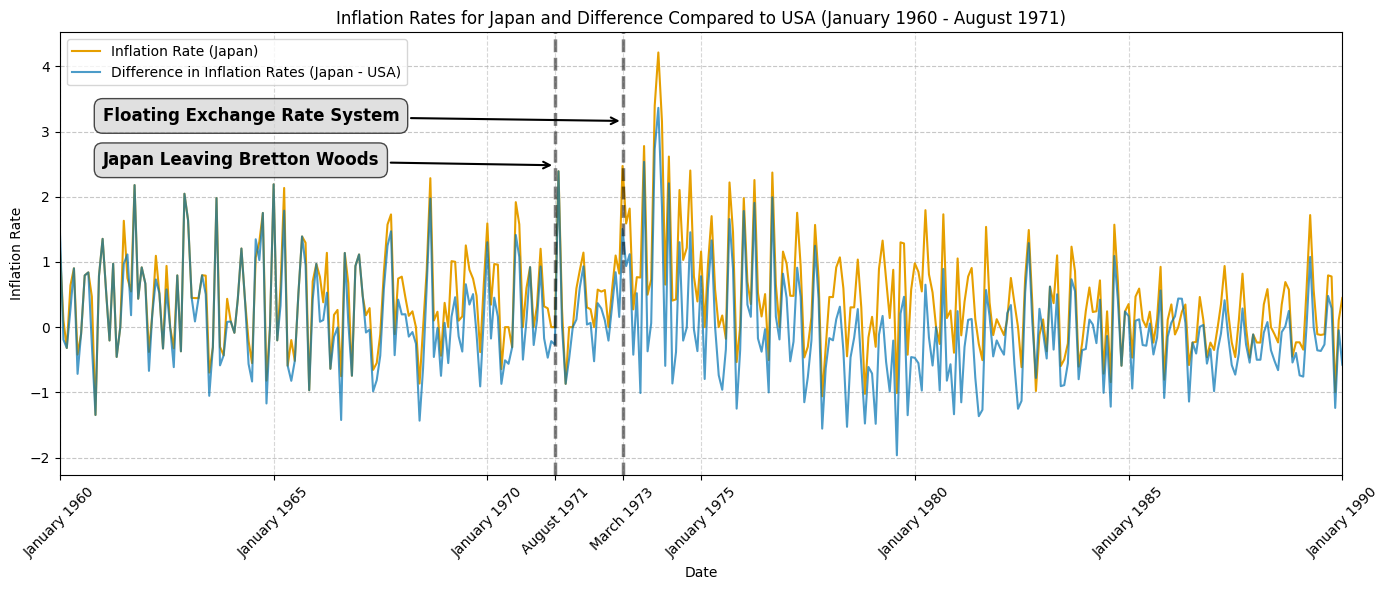

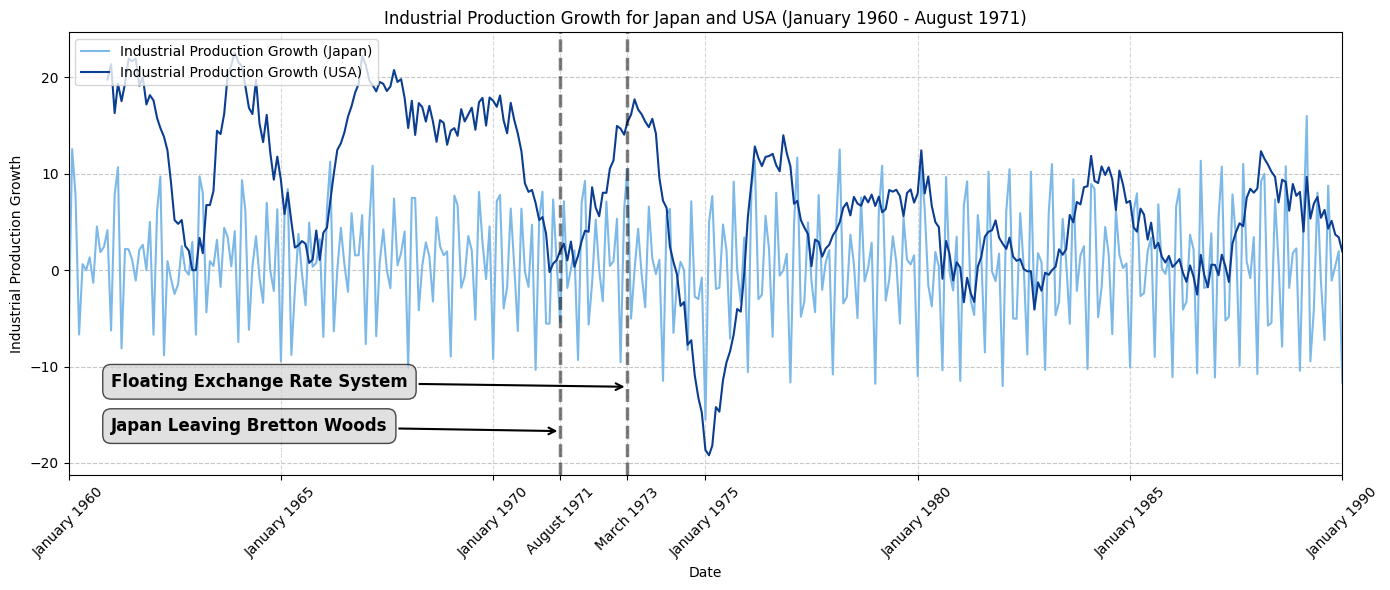

In [150]:
plot_inflation_graph(graph_2_df)
plot_industrial_graph(graph_2_df)

In [50]:
during_bretton_wood = merged_df[(merged_df['date'] >= '1960-01-01') & (merged_df['date'] <= '1971-06-01')]
after_bretton_wood = merged_df[(merged_df['date'] >= '1973-03-01')]

display(during_bretton_wood)
display(after_bretton_wood)

,index,date,industrial_production_japan,nominal_exchange_rate_japan,reserves_japan,cpi_japan,reserves_usa,cpi_usa,nominal_ex_rate_growth_japan,real_exchange_rate_japan,real_ex_rate_growth_japan,real_exchange_rate_index,inflation_rate_japan,ind_prod_growth_japan,ind_prod_growth_12m_japan,reserves_index_japan,inflation_rate_usa,reserves_index_usa,outlier_flag
0,1,1960-01-01,11.23,360.0,1453.30,18.75,21478.10,13.44,0.0,258.048000,-1.519763,3.021141,1.241901,-7.495881,NaN,100.000000,-0.296736,100.000000,Normal
1,2,1960-02-01,12.64,360.0,1446.33,18.77,21395.70,13.48,0.0,258.540224,0.190749,3.026904,0.106667,12.555654,NaN,99.520402,0.297619,99.616353,Normal
2,3,1960-03-01,13.63,360.0,1486.37,18.71,21344.70,13.48,0.0,259.369321,0.320684,3.036610,-0.319659,7.832278,NaN,102.275511,0.000000,99.378902,Normal
3,4,1960-04-01,12.72,360.0,1510.40,18.83,21278.00,13.53,0.0,258.672331,-0.268725,3.028450,0.641368,-6.676449,NaN,103.928989,0.370920,99.068353,Normal
4,5,1960-05-01,12.80,360.0,1544.47,19.00,21234.30,13.53,0.0,256.357895,-0.894737,3.001354,0.902815,0.628931,NaN,106.273309,0.000000,98.864890,Normal
5,6,1960-06-01,12.80,360.0,1576.00,18.92,21169.80,13.57,0.0,258.202960,0.719722,3.022955,-0.421053,0.000000,NaN,108.442854,0.295639,98.564584,Normal
6,7,1960-07-01,12.97,360.0,1629.54,18.90,20999.40,13.57,0.0,258.476190,0.105820,3.026154,-0.105708,1.328125,NaN,112.126884,0.000000,97.771218,Normal
7,8,1960-08-01,12.80,360.0,1693.96,19.05,20803.40,13.57,0.0,256.440945,-0.787402,3.002326,0.793651,-1.310717,NaN,116.559554,0.000000,96.858661,Normal
8,9,1960-09-01,13.38,360.0,1782.99,19.21,20430.00,13.57,0.0,254.305049,-0.832900,2.977320,0.839895,4.531250,NaN,122.685612,0.000000,95.120146,Normal
9,10,1960-10-01,13.63,360.0,1842.03,19.30,20068.20,13.67,0.0,254.984456,0.267162,2.985274,0.468506,1.868460,NaN,126.748091,0.736920,93.435639,Normal


,index,date,industrial_production_japan,nominal_exchange_rate_japan,reserves_japan,cpi_japan,reserves_usa,cpi_usa,nominal_ex_rate_growth_japan,real_exchange_rate_japan,real_ex_rate_growth_japan,real_exchange_rate_index,inflation_rate_japan,ind_prod_growth_japan,ind_prod_growth_12m_japan,reserves_index_japan,inflation_rate_usa,reserves_index_usa,outlier_flag
158,159,1973-03-01,60.71,265.26,18125.49,38.96,13201.41,19.86,-4.958796,135.217238,-6.355995,1.583079,2.472383,10.522483,15.374382,1247.195349,0.965938,61.464515,Normal
159,160,1973-04-01,57.66,265.52,16835.81,39.58,13172.79,19.99,0.098017,134.101688,-0.825006,1.570018,1.591376,-5.023884,16.132931,1158.453864,0.654582,61.331263,Normal
160,161,1973-05-01,57.66,264.73,15869.42,40.30,13184.89,20.13,-0.297529,132.233620,-1.393023,1.548148,1.819101,0.000000,17.721519,1091.957614,0.700350,61.387599,Normal
161,162,1973-06-01,60.14,264.70,15199.63,40.41,13183.16,20.27,-0.011332,132.775773,0.409996,1.554495,0.272953,4.301075,16.663434,1045.870089,0.695479,61.379545,Normal
162,163,1973-07-01,59.89,264.41,15157.57,40.72,13187.86,20.32,-0.109558,131.945265,-0.625497,1.544772,0.767137,-0.415697,16.178468,1042.975986,0.246670,61.401428,Normal
163,164,1973-08-01,57.58,265.11,15126.29,41.03,13193.41,20.68,0.264740,133.621126,1.270118,1.564392,0.761297,-3.857071,15.413911,1040.823643,1.771654,61.427268,Normal
164,165,1973-09-01,61.38,265.49,14795.09,42.17,13198.00,20.73,0.143337,130.510024,-2.328301,1.527968,2.778455,6.599514,14.836296,1018.034129,0.241779,61.448638,Normal
165,166,1973-10-01,62.12,266.33,14048.86,42.38,14367.46,20.91,0.316396,131.405387,0.686049,1.538451,0.497984,1.205604,15.701248,966.686851,0.868307,66.893533,Normal
166,167,1973-11-01,61.87,277.81,13196.34,42.69,14372.77,21.05,4.310442,136.985254,4.246300,1.603778,0.731477,-0.402447,14.172357,908.025872,0.669536,66.918256,Normal
167,168,1973-12-01,62.53,280.00,12245.78,44.14,14377.96,21.19,0.788309,134.417762,-1.874284,1.573719,3.396580,1.066753,9.548003,842.618867,0.665083,66.942420,Normal


## 5.2.3 Comparison Statistics & Visualisation
Separately for both the period before and after Bretton Woods, calculate the standard deviation of
the following variables and report these values in a suitably formatted table as well as the ratio of the
standard deviation of each variable before and after Bretton Woods:
- The monthly growth of the nominal exchange rate versus the US dollar.
- The monthly growth of the real exchange rate versus the US dollar.
- The inflation rate in your country.
- The difference between the inflation in your country versus the United States.
- The 12-monthly industrial production growth.

When you calculate the standard deviation of variables before Bretton Woods, include data up to
06/1971. When you calculate the standard deviation of variables after Bretton Woods, only include
data from 03/1973.
- Why might it be a good idea to exclude data from 07/1971 - 02/1973 for the above calculations?


Present the standard deviations you calculated above in a chart and give it an informative title.
For the inflation rate, difference in inflation and the 12-montly industrial production growth, plot
the yearly standard deviation of the variable over time and also indicate on your graph the standard
deviation of the variable for the pre and post Bretton Woods periods.
- e.g. for monthly inflation, you should have 31 datapoints showing the standard deviation of inflation in each year from 1960 - 1990. How you display the standard deviation for the pre and post
Bretton Woods periods on the chart is up to you.


In [70]:
def calculate_standard_deviations(df): 
    during_bretton_wood = df[(df['date'] >= '1960-01-01') & (df['date'] <= '1971-06-01')]
    after_bretton_wood = df[(df['date'] >= '1973-03-01')]

    variables = [
        'nominal_ex_rate_growth_japan',  # Monthly growth of nominal exchange rate
        'real_ex_rate_growth_japan',     # Monthly growth of real exchange rate
        'inflation_rate_japan',               # Inflation rate in Japan
        'difference_in_inflation_rates',                # Difference between Japan and US inflation
        'ind_prod_growth_12m_japan'          # 12-month industrial production growth
    ]
     
    results = []
    for var in variables:
        during_std = during_bretton_wood[var].std()
        after_std = after_bretton_wood[var].std()
        ratio = during_std / after_std
        
        results.append({
            'Variable': var,
            'Pre-Bretton Woods SD': during_std,
            'Post-Bretton Woods SD': after_std,
            'Ratio (Post/Pre)': ratio
        })
    
    # Create DataFrame with results
    results_df = pd.DataFrame(results)

    return results_df

standard_deviations = calculate_standard_deviations(merged_df)

In [72]:
def create_markdown_table(df):
    # Create better variable names for display
    variable_names = {
        'nominal_ex_rate_growth_japan': 'Nominal Exchange Rate Growth',
        'real_ex_rate_growth_japan': 'Real Exchange Rate Growth',
        'inflation_rate_japan': 'Japan Inflation Rate',
        'difference_in_inflation_rates': 'Japan-US Inflation Difference',
        'ind_prod_growth_12m_japan': 'Industrial Production Growth (12m)'
    }
    
    # Format the values to 4 decimal places
    df_formatted = df.copy()
    df_formatted['Variable'] = df_formatted['Variable'].map(variable_names)
    df_formatted['Pre-Bretton Woods SD'] = df_formatted['Pre-Bretton Woods SD'].map('{:.4f}'.format)
    df_formatted['Post-Bretton Woods SD'] = df_formatted['Post-Bretton Woods SD'].map('{:.4f}'.format)
    df_formatted['Ratio (Post/Pre)'] = df_formatted['Ratio (Post/Pre)'].map('{:.4f}'.format)
    
    # Create markdown table header
    markdown_table = "### Standard Deviations Before and After Bretton Woods\n\n"
    markdown_table += "| Variable | Pre-Bretton Woods SD | Post-Bretton Woods SD | Ratio (Pre/Post) |\n"
    markdown_table += "|:---------|:--------------------:|:---------------------:|:----------------:|\n"
    
    # Add each row
    for _, row in df_formatted.iterrows():
        markdown_table += f"| {row['Variable']} | {row['Pre-Bretton Woods SD']} | {row['Post-Bretton Woods SD']} | {row['Ratio (Post/Pre)']} |\n"
    
    return markdown_table

# Generate the markdown table
markdown_table = create_markdown_table(standard_deviations)
print(markdown_table)

### Standard Deviations Before and After Bretton Woods

| Variable | Pre-Bretton Woods SD | Post-Bretton Woods SD | Ratio (Pre/Post) |
|:---------|:--------------------:|:---------------------:|:----------------:|
| Nominal Exchange Rate Growth | 0.0000 | 2.8384 | 0.0000 |
| Real Exchange Rate Growth | 0.7862 | 2.9819 | 0.2637 |
| Japan Inflation Rate | 0.7499 | 0.8243 | 0.9097 |
| Japan-US Inflation Difference | 0.7931 | 0.7976 | 0.9944 |
| Industrial Production Growth (12m) | 6.3887 | 6.3718 | 1.0026 |



### Standard Deviations Before and After Bretton Woods

| Variable | Pre-Bretton Woods SD | Post-Bretton Woods SD | Ratio (Pre/Post) |
|:---------|:--------------------:|:---------------------:|:----------------:|
| Nominal Exchange Rate Growth | 0.0000 | 2.8384 | 0.0000 |
| Real Exchange Rate Growth | 0.7862 | 2.9819 | 0.2637 |
| Japan Inflation Rate | 0.7499 | 0.8243 | 0.9097 |
| Japan-US Inflation Difference | 0.7931 | 0.7976 | 0.9944 |
| Industrial Production Growth (12m) | 6.3887 | 6.3718 | 1.0026 |

In [73]:
display(standard_deviations)

,Variable,Pre-Bretton Woods SD,Post-Bretton Woods SD,Ratio (Post/Pre)
0,nominal_ex_rate_growth_japan,0.000000,2.838365,0.000000
1,real_ex_rate_growth_japan,0.786225,2.981866,0.263669
2,inflation_rate_japan,0.749888,0.824314,0.909712
3,difference_in_inflation_rates,0.793123,0.797572,0.994422
4,ind_prod_growth_12m_japan,6.388662,6.371798,1.002647


In [101]:
def plot_standard_deviations_graph(df):
    # Assuming standard_deviations is a pandas DataFrame
    pre_bretton = df['Pre-Bretton Woods SD']
    post_bretton = df['Post-Bretton Woods SD']
    ratio = df['Ratio (Post/Pre)']

    bar_width = 0.3
    x = np.arange(len(df))

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot bars for Pre- and Post-Bretton Woods periods
    ax.bar(x - bar_width/2, pre_bretton, bar_width, label="Pre-Bretton Woods", color='#33A1C9')
    ax.bar(x + bar_width/2, post_bretton, bar_width, label="Post-Bretton Woods", color='#ffae42')

    # Increase ylim to give more space for ratio boxes
    ax.set_ylim(0, max(post_bretton.max(), pre_bretton.max()) + 1)

    # Add ratio labels above bars
    for i in range(len(ratio)):
        max_height = max(pre_bretton.iloc[i], post_bretton.iloc[i])
        ax.text(x[i], max_height + 0.3, f"Ratio: {ratio.iloc[i]:.3f}", ha='center', fontsize=10,
                bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3'))

    # Add labels and title
    ax.set_xticks(x)
    ax.set_xticklabels(['Nominal Exchange Rate Growth', 'Real Exchange Rate Growth', 'Japan Inflation Rate', 'Japan-US Inflation Difference', 'Industrial Production Growth (12m)'], 
                    rotation=45, weight='bold', size=10)
    ax.set_ylabel("Standard Deviation")
    ax.set_title("Comparison of Standard Deviations: Pre vs. Post Bretton Woods", fontsize=18, weight='bold')

    # Add legend
    ax.legend()

    # Show plot
    plt.show()

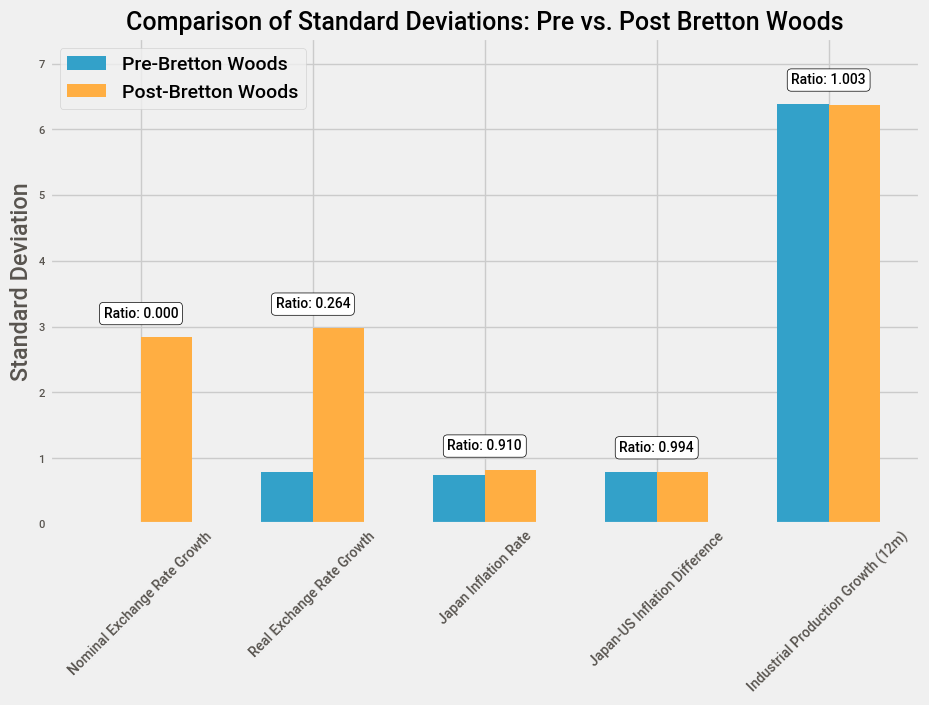

In [102]:
plot_standard_deviations_graph(standard_deviations)

In [104]:
def create_yearly_standard_deviation(df): 
    variables = ['inflation_rate_japan', 'difference_in_inflation_rates', 'ind_prod_growth_12m_japan']
    df['year'] = df['date'].dt.year
    std_dev = df.groupby('year')[variables].std().reset_index()
    return std_dev

yearly_standard_deviations = create_yearly_standard_deviation(merged_df)


In [ ]:
style.use('default')

In [122]:
def plot_yearly_std_graph(yearly_std_df):
    # Ensure that the 'year' column is numeric
    yearly_std_df['date'] = pd.to_datetime(yearly_std_df['year'].astype(str) + '-01-01')
    
    # Plot
    fig, ax = plt.subplots(figsize=(14, 6))  # Increase figure width
    
    # Plot standard deviations with more contrasting colors
    sns.lineplot(x=yearly_std_df['date'], y=yearly_std_df['inflation_rate_japan'], ax=ax, 
                 label='Inflation Rate SD (Japan)', color='#00BFFF')  # Deep Sky Blue
    sns.lineplot(x=yearly_std_df['date'], y=yearly_std_df['difference_in_inflation_rates'], ax=ax, 
                 label='Japan-US Inflation Difference SD', color='#000080')  # Navy Blue
    sns.lineplot(x=yearly_std_df['date'], y=yearly_std_df['ind_prod_growth_12m_japan'], ax=ax, 
                 label='Industrial Production Growth SD', color='#1B4D3E')  
    
    # Labels
    ax.set_xlabel('Year')
    ax.set_ylabel('Annual Standard Deviation')
    
    # Create custom ticks for every 5 years
    start_year = yearly_std_df['year'].min()
    end_year = yearly_std_df['year'].max()
    year_range = list(range(start_year - start_year % 5, end_year + 5, 5))
    regular_ticks = [pd.to_datetime(f"{year}-01-01") for year in year_range]
    
    # Add August 1971 and March 1973 ticks
    august_1971 = pd.to_datetime('1971-08-01')
    march_1973 = pd.to_datetime('1973-03-01')
    
    # Combine all ticks and sort them
    all_ticks = regular_ticks + [august_1971, march_1973]
    all_ticks.sort()
    
    # Convert datetime ticks to matplotlib's numerical format
    tick_nums = [mdates.date2num(tick) for tick in all_ticks]
    
    # Set the ticks
    ax.set_xticks(tick_nums)
    
    # Create corresponding labels
    tick_labels = []
    for tick in all_ticks:
        if tick.month == 8 and tick.year == 1971:
            tick_labels.append('August 1971')
        elif tick.month == 3 and tick.year == 1973:
            tick_labels.append('March 1973')
        else:
            tick_labels.append(f'{tick.year}')
    
    # Set the tick labels
    ax.set_xticklabels(tick_labels, rotation=45)
    
    # Add vertical lines at August 1971 and March 1973
    ax.axvline(x=mdates.date2num(august_1971), color='black', linestyle='--', linewidth=2.5, alpha=0.5)
    ax.axvline(x=mdates.date2num(march_1973), color='black', linestyle='--', linewidth=2.5, alpha=0.5)
    
    # Add a horizontal line for the average SD before and after Bretton Woods
    before_bretton = yearly_std_df[yearly_std_df['date'] < pd.to_datetime('1971-08-01')]
    after_bretton = yearly_std_df[yearly_std_df['date'] >= pd.to_datetime('1973-03-01')]
    
    # Use the same contrasting colors for the horizontal averages
    colors = {
        'inflation_rate_japan': '#00BFFF',        # Deep Sky Blue
        'difference_in_inflation_rates': '#000080', # Navy Blue
        'ind_prod_growth_12m_japan': '#1B4D3E'    
    }
    
    # Calculate average SDs for all variables before and after
    for var in colors:
        before_avg = before_bretton[var].mean()
        after_avg = after_bretton[var].mean()
        
        # Add horizontal lines for average SD
        ax.axhline(y=before_avg, color=colors[var], linestyle=':', linewidth=1.5, alpha=0.5,
                  xmin=0, xmax=(mdates.date2num(august_1971) - mdates.date2num(pd.to_datetime('1960-01-01'))) / 
                  (mdates.date2num(pd.to_datetime('1990-01-01')) - mdates.date2num(pd.to_datetime('1960-01-01'))))
        
        ax.axhline(y=after_avg, color=colors[var], linestyle=':', linewidth=1.5, alpha=0.5,
                  xmin=(mdates.date2num(march_1973) - mdates.date2num(pd.to_datetime('1960-01-01'))) / 
                  (mdates.date2num(pd.to_datetime('1990-01-01')) - mdates.date2num(pd.to_datetime('1960-01-01'))),
                  xmax=1)
    
    # Get y-axis limits to position annotations better
    y_min, y_max = ax.get_ylim()
    y_range = y_max - y_min
    
    # Add annotation for August 1971 - SHIFTED TO TOP RIGHT
    ax.annotate('Japan Leaving Bretton Woods', 
                xy=(mdates.date2num(august_1971), 0.9),  # Arrow tip position - high
                xytext=(mdates.date2num(pd.to_datetime('1980-01-01')), 0.9),  # Text position - top right
                xycoords=('data', 'axes fraction'),
                textcoords=('data', 'axes fraction'),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='black'),
                fontsize=12, 
                fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.5", fc="lightgrey", ec="black", alpha=0.7))
    
    # Add annotation for March 1973 - SHIFTED TO TOP RIGHT
    ax.annotate('Floating Exchange Rate System', 
                xy=(mdates.date2num(march_1973), 0.8),  # Arrow tip position - high
                xytext=(mdates.date2num(pd.to_datetime('1980-01-01')), 0.8),  # Text position - top right
                xycoords=('data', 'axes fraction'),
                textcoords=('data', 'axes fraction'),
                arrowprops=dict(arrowstyle='->', lw=1.5, color='black'),
                fontsize=12, 
                fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.5", fc="lightgrey", ec="black", alpha=0.7))
    
    # Shade the transition period
    ax.axvspan(mdates.date2num(august_1971), mdates.date2num(march_1973), 
               alpha=0.2, color='gray', label='Transition Period')
    
    # Adjust x-axis limits if necessary
    ax.set_xlim(pd.to_datetime(f"{start_year}-01-01"), pd.to_datetime(f"{end_year}-12-31"))
    
    # Add gridlines
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)
    
    # Legend
    ax.legend(loc='upper left')
    
    plt.title('Yearly Standard Deviations: Comparison Before and After Bretton Woods')
    plt.tight_layout()  # Adjust the layout to prevent overlap
    plt.show()

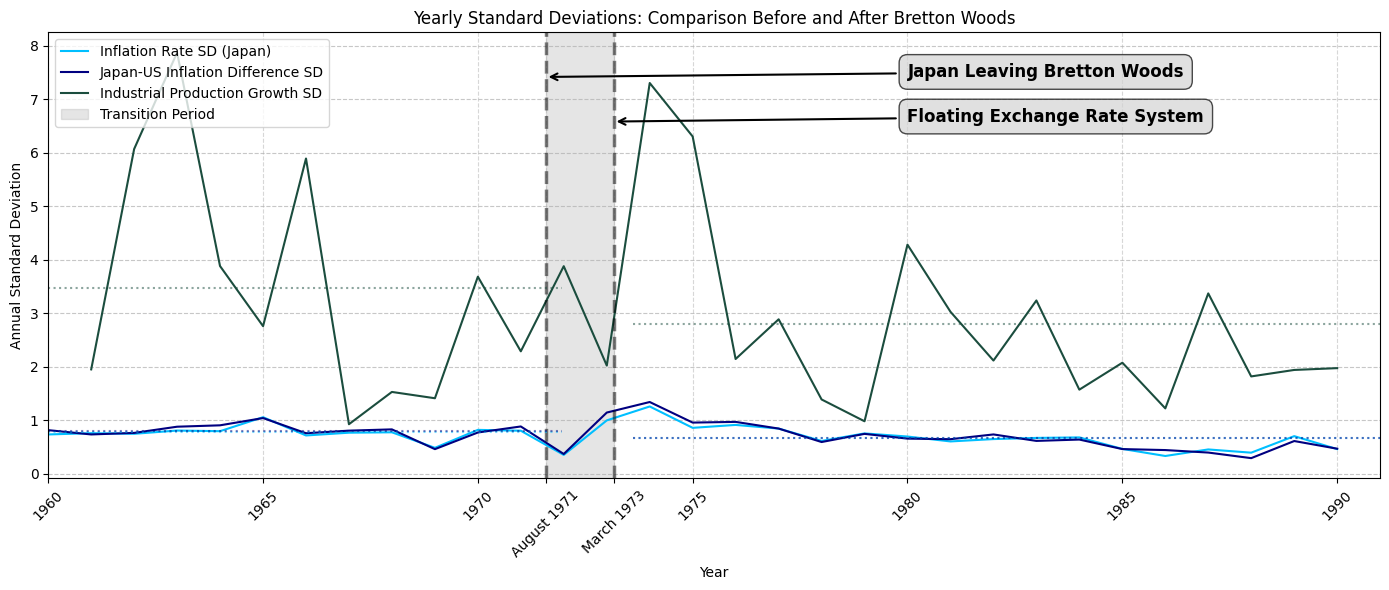

In [123]:
plot_yearly_std_graph(yearly_standard_deviations)

## 5.2.4 Regression Analysis
For every 6-month period (e.g. Jan - Jun and Jul - Dec), calculate the standard deviation for the
following variables:
- The monthly growth in the real exchange rate.
- The inflation difference between your country versus the US.
- The 12-monthly industrial production growth.

Manually confirm that your code is correct by checking a particular 6-month period for each variable.

Run regressions with the 6-monthly standard deviation of the inflation difference and the 12-monthly
industrial production growth as the dependent variable, and the 6-monthly standard deviation in the
monthly growth of the real exchange rate as the independent variable. Comment on the results.

Show side-by-side graphs with the 6-monthly standard deviation of the monthly growth in the real
exchange rate on the x-axis and the dependent variables on the y-axis. Include both a linear and
second-degree line of best fit, as well as an appropriate title that conveys the key point of your graphs.
- Think about how you can use colours or other formatting to show the key point from your graphs
as clearly as possible.
- What regressions have been implicitly run to produce these different lines of best fit?

In [128]:
def create_six_month_intervals(df):
    # Make a copy of the dataframe to avoid modifying the original
    df_copy = df.copy()
    
    # Ensure date column is datetime
    df_copy['date'] = pd.to_datetime(df_copy['date'])
    
    # Extract year and month
    df_copy['year'] = df_copy['date'].dt.year
    df_copy['month'] = df_copy['date'].dt.month
    
    # Create semester indicator (1 for Jan-Jun, 2 for Jul-Dec)
    df_copy['semester'] = ((df_copy['month'] - 1) // 6) + 1
    
    # Create period label in format "YYYY/S" where S is 1 or 2
    df_copy['period'] = df_copy['year'].astype(str) + '/' + df_copy['semester'].astype(str)
    
    return df_copy

# Apply the function to create intervals
merged_df_with_periods = create_six_month_intervals(merged_df)

# If you want to calculate standard deviations by period instead of means:
period_std = merged_df_with_periods.groupby('period').agg({
    'nominal_exchange_rate_japan': 'std',
    'real_exchange_rate_index': 'std',
    'inflation_rate_japan': 'std',
    # Add other variables as needed
    'ind_prod_growth_12m_japan': 'std'
})

display(period_std)


,nominal_exchange_rate_japan,real_exchange_rate_index,inflation_rate_japan,ind_prod_growth_12m_japan
period,,,,
1960/1,0.000000,0.011850,0.676419,NaN
1960/2,0.000000,0.020204,0.855252,NaN
1961/1,0.000000,0.013193,0.707941,2.167084
1961/2,0.000000,0.053461,0.684733,1.899474
1962/1,0.000000,0.015083,0.580349,2.961726
1962/2,0.000000,0.022849,0.933881,2.128962
1963/1,0.000000,0.022518,0.463268,3.258290
1963/2,0.000000,0.018359,0.988993,3.667806
1964/1,0.000000,0.022592,0.512150,2.206952


In [138]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

def create_regression_models(period_std): 
    # Drop rows where any of the relevant columns have missing values
    df_cleaned = period_std.dropna(subset=['real_exchange_rate_index', 'inflation_rate_japan', 'ind_prod_growth_12m_japan'])

    # Now extract the cleaned data
    X = df_cleaned[['real_exchange_rate_index']]  # Independent variable
    y_inflation = df_cleaned['inflation_rate_japan']  # Dependent variable 1
    y_industrial = df_cleaned['ind_prod_growth_12m_japan']  # Dependent variable 2

    # Now that we have cleaned data, we can safely check the lengths
    assert len(X) == len(y_inflation) == len(y_industrial)

    # Linear Regression Model for Inflation Difference
    linear_model_inflation = LinearRegression().fit(X, y_inflation)

    # Polynomial Regression Model (2nd Degree) for Inflation Difference
    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X)
    poly_model_inflation = LinearRegression().fit(X_poly, y_inflation)

    # Linear Regression Model for Industrial Growth
    linear_model_industrial = LinearRegression().fit(X, y_industrial)

    # Polynomial Regression Model (2nd Degree) for Industrial Growth
    poly_model_industrial = LinearRegression().fit(X_poly, y_industrial)

    # Predictions
    y_inflation_pred_linear = linear_model_inflation.predict(X)
    y_inflation_pred_poly = poly_model_inflation.predict(X_poly)

    y_industrial_pred_linear = linear_model_industrial.predict(X)
    y_industrial_pred_poly = poly_model_industrial.predict(X_poly)

    # Calculate Mean Squared Error (MSE) for both models
    mse_inflation_linear = mean_squared_error(y_inflation, y_inflation_pred_linear)
    mse_inflation_poly = mean_squared_error(y_inflation, y_inflation_pred_poly)

    mse_industrial_linear = mean_squared_error(y_industrial, y_industrial_pred_linear)
    mse_industrial_poly = mean_squared_error(y_industrial, y_industrial_pred_poly)

    print(f"Linear Regression MSE (Inflation Difference): {mse_inflation_linear}")
    print(f"Polynomial Regression MSE (Inflation Difference): {mse_inflation_poly}")
    print(f"Linear Regression MSE (Industrial Growth): {mse_industrial_linear}")
    print(f"Polynomial Regression MSE (Industrial Growth): {mse_industrial_poly}")

    # Plotting - fixed version
    plt.figure(figsize=(14, 6))

    # Create sorted X values for smooth curves - KEEP DATAFRAME FORMAT
    X_sort = pd.DataFrame(np.sort(X.values, axis=0), columns=['real_exchange_rate_index'])
    X_poly_sort = poly.fit_transform(X_sort)

    # Generate predictions with sorted values
    y_inflation_pred_linear_sort = linear_model_inflation.predict(X_sort)
    y_inflation_pred_poly_sort = poly_model_inflation.predict(X_poly_sort)
    y_industrial_pred_linear_sort = linear_model_industrial.predict(X_sort)
    y_industrial_pred_poly_sort = poly_model_industrial.predict(X_poly_sort)

    # Inflation Difference
    plt.subplot(1, 2, 1)
    plt.scatter(X, y_inflation, color='blue', label='Inflation Data')
    plt.plot(X_sort, y_inflation_pred_linear_sort, color='red', label='Linear Fit')
    plt.plot(X_sort, y_inflation_pred_poly_sort, color='green', label='Polynomial Fit')
    plt.title('Inflation Difference vs. Real Exchange Rate Growth Std')
    plt.xlabel('6-Month Std of Real Exchange Rate Growth')
    plt.ylabel('6-Month Std of Inflation Difference')
    plt.legend()

    # Industrial Growth
    plt.subplot(1, 2, 2)
    plt.scatter(X, y_industrial, color='orange', label='Industrial Growth Data')
    plt.plot(X_sort, y_industrial_pred_linear_sort, color='red', label='Linear Fit')
    plt.plot(X_sort, y_industrial_pred_poly_sort, color='green', label='Polynomial Fit')
    plt.title('Industrial Growth vs. Real Exchange Rate Growth Std')
    plt.xlabel('6-Month Std of Real Exchange Rate Growth')
    plt.ylabel('6-Month Std of Industrial Growth')
    plt.legend()

    plt.tight_layout()
    plt.show()
    return 


Linear Regression MSE (Inflation Difference): 0.070131964738882
Polynomial Regression MSE (Inflation Difference): 0.07004467072044027
Linear Regression MSE (Industrial Growth): 0.7511991573694073
Polynomial Regression MSE (Industrial Growth): 0.7456676802417058


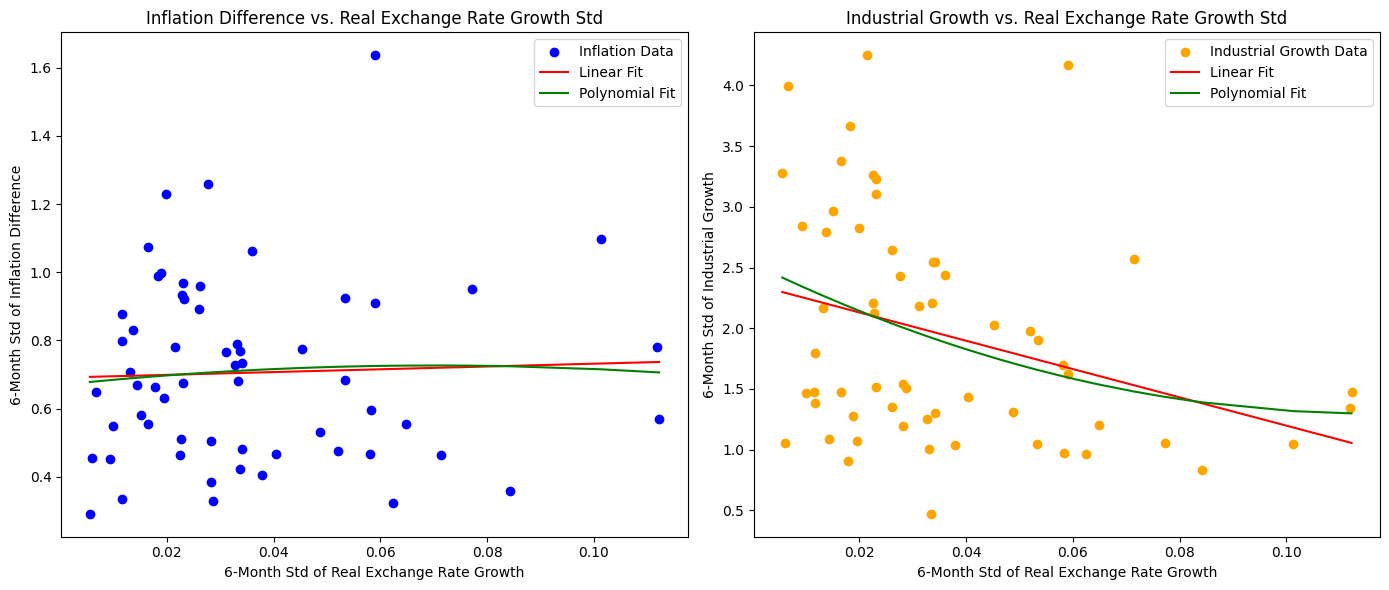

In [139]:
create_regression_models(period_std)